In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import joblib
import os
import requests
from huggingface_hub import login, HfApi
import warnings
warnings.filterwarnings('ignore')

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_csv(
    '/content/drive/MyDrive/Project1_RE_Price_Predictor/data/processed/master_dataset.csv',
    dtype={'zip_code': str},
    parse_dates=['prev_sold_date'],
)
print((df['city'] == 'Out Of County').sum())
print((df['zip_code'] == '99999').sum())

0
0


In [11]:
df.shape[0]

2224841

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2224841 entries, 0 to 2224840
Data columns (total 39 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   brokered_by                           float64       
 1   status                                object        
 2   price                                 float64       
 3   bed                                   float64       
 4   bath                                  float64       
 5   acre_lot                              float64       
 6   street                                float64       
 7   city                                  object        
 8   state                                 object        
 9   zip_code                              object        
 10  house_size                            float64       
 11  prev_sold_date                        datetime64[ns]
 12  is_missing_bed                        int64         
 13  is_missing_b

In [13]:
df.isnull().sum()

,0
brokered_by,4533
status,0
price,410
bed,482224
bath,511777
acre_lot,329802
street,10864
city,1410
state,8
zip_code,0


## Missing Values in the Master Dataset

Missing values in `master_dataset.csv` fall into three groups, each with a different cause.

### Near-complete columns

`status`, `zip_code`, and `state` are effectively fully populated, and `price` (the target) is missing in only 410 of 2.2M rows. `city`, `street`, and `brokered_by` have negligible gaps under 0.5%.

### Property attributes

`bed` (21.7%), `bath` (23.0%), `acre_lot` (14.8%), and `house_size` (25.5%) have moderate missingness that is **structural rather than random**. Missingness correlates with listing `status`:

- `ready_to_build` listings are missing `bath` **100%** of the time — bathroom counts are not recorded for pre-construction properties
- `for_sale` listings are missing these fields at roughly **3x** the rate of `sold` listings

Indicator flags (`is_missing_bed`, `is_missing_bath`, `is_missing_house_size`) were added so this pattern remains available to the model as signal.

### Market-context columns

The merged Redfin, Realtor.com, and Zillow features are missing in 38–55% of rows, from two separate causes:

1. **No date to match on** — 733,257 rows (33%) have no `prev_sold_date`. These are `for_sale` and `ready_to_build` listings with no prior transaction, so they receive no market context by design.
2. **Source coverage gaps** — among matchable rows, some zip/period combinations simply have no data. Redfin suppresses medians in low-volume zips (20.5% missing where `homes_sold` ≤ 3, vs 4.6% overall), and Zillow's coverage expanded over time (~51% missing in 2000 → near 0% by 2024).

### Why nothing was imputed

Missingness in this dataset is consistently **informative rather than random**. Filling gaps with means or medians would fabricate data precisely where the underlying information is least reliable — a low-volume zip with no computable median is genuinely different from one with a known median. Values are left as `NaN`, which tree-based models handle natively and can split on directly.

In [14]:
df.duplicated().sum()

np.int64(9)

In [15]:
df.shape

(2224841, 39)

In [16]:
# 1. Confirm the missing-chunk theory: exact shortfall
print(f"Expected rows: 2,224,841 | Actual rows: {df.shape[0]:,} | Missing: {2224841 - df.shape[0]:,}")

# 2. Force prev_sold_date to real datetime, see how many fail beyond the expected 733,257 no-date rows
df['prev_sold_date'] = pd.to_datetime(df['prev_sold_date'], errors='coerce')
print(f"prev_sold_date NaT count: {df['prev_sold_date'].isna().sum():,} (expected ~733,257)")

# 3. Force bed to numeric, see how many values don't convert
bad_bed = pd.to_numeric(df['bed'], errors='coerce')
print(f"bed values that failed numeric conversion: {(bad_bed.isna() & df['bed'].notna()).sum():,}")
df['bed'] = bad_bed

# 4. Drop the 9 duplicates
df = df.drop_duplicates()

Expected rows: 2,224,841 | Actual rows: 2,224,841 | Missing: 0
prev_sold_date NaT count: 733,257 (expected ~733,257)
bed values that failed numeric conversion: 0


In [17]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
brokered_by,2220299.0,52936.959641,0.0,23859.0,52882.0,79183.0,110142.0,30643.576362
price,2224423.0,517499.882339,1.0,165000.0,325000.0,550000.0,50000000.0,1048611.28918
bed,1742616.0,3.255626,1.0,3.0,3.0,4.0,15.0,1.151792
bath,1713064.0,2.483602,1.0,2.0,2.0,3.0,15.0,1.156185
acre_lot,1895034.0,4.187213,0.01,0.15,0.26,0.98,640.0,23.503782
street,2213969.0,1012267.860368,0.0,506293.0,1012691.0,1521060.0,2001357.0,583738.812389
house_size,1656807.0,2033.237413,100.0,1300.0,1760.0,2412.0,50000.0,1297.248474
prev_sold_date,1491583,2017-08-16 15:10:18.096345088,1901-01-01 00:00:00,2016-08-09 00:00:00,2021-12-01 00:00:00,2022-03-04 00:00:00,2026-04-08 00:00:00,NaN
is_missing_bed,2224832.0,0.216743,0.0,0.0,0.0,0.0,1.0,0.412026
is_missing_bath,2224832.0,0.230025,0.0,0.0,0.0,0.0,1.0,0.420849


In [18]:
df.groupby('status')['price'].describe().T

status,for_sale,ready_to_build,sold
count,1.388216e+06,2.445200e+04,8.117550e+05
mean,5.376374e+05,5.148190e+05,4.831426e+05
std,1.219248e+06,2.508900e+05,6.834821e+05
min,1.000000e+00,1.150000e+05,1.000000e+00
25%,1.350000e+05,3.719900e+05,2.020000e+05
50%,3.050000e+05,4.559900e+05,3.449000e+05
75%,5.499000e+05,5.769900e+05,5.500000e+05
max,5.000000e+07,4.900000e+06,4.999500e+07


### Invalid Values in Merged Market-Context Columns

Outlier cleaning was originally applied only to the primary Kaggle listing data. A full `describe()` on the merged dataset revealed that several market-context columns carried their own impossible values, concentrated in the Realtor.com source:

| Column | Invalid range found | Rows affected |
|---|---|---|
| `median_listing_price_per_square_foot` | 0 to 231,506 | 1,079 (0.048%) |
| `median_ppsf` | as low as \$0.10/sqft | 293 (0.013%) |
| `price_reduced_share` | up to 4.0 (should be ≤ 1.0) | 95 (0.004%) |
| `median_listing_price` | as low as \$1 | 94 (0.004%) |
| `average_listing_price` | as low as \$1 | 36 (0.002%) |
| `median_square_feet` | 10 to 153,870 sqft | 16 (0.001%) |
| `price_increased_share` | up to 4.0 (should be ≤ 1.0) | 7 (0.000%) |

All affected fractions are below 0.05% of the dataset. Consistent with the treatment applied to the Kaggle columns, these values were set to `NaN` rather than dropped — the row's remaining valid fields are retained, and only the impossible measurement is removed. This adds a negligible amount to overall missingness while preventing clearly erroneous values from distorting model training.

The Redfin columns were otherwise clean (`avg_sale_to_list` 0.50–1.95, `sold_above_list` 0–1, `homes_sold` 1–2,680), and Zillow's `zhvi` range of \$10,769–\$8.2M is wide but plausible across US ZIP codes.

In [19]:
df.loc[(df['median_listing_price_per_square_foot'] <= 0) | (df['median_listing_price_per_square_foot'] > 2000), 'median_listing_price_per_square_foot'] = np.nan
df.loc[(df['median_square_feet'] < 300) | (df['median_square_feet'] > 15000), 'median_square_feet'] = np.nan
df.loc[df['price_increased_share'] > 1, 'price_increased_share'] = np.nan
df.loc[df['price_reduced_share'] > 1, 'price_reduced_share'] = np.nan
df.loc[df['median_listing_price'] < 10000, 'median_listing_price'] = np.nan
df.loc[df['average_listing_price'] < 10000, 'average_listing_price'] = np.nan
df.loc[(df['median_ppsf'] < 10) | (df['median_ppsf'] > 3000), 'median_ppsf'] = np.nan

In [20]:
checks = {
    'median_listing_price_per_square_foot': (df['median_listing_price_per_square_foot'] <= 0) | (df['median_listing_price_per_square_foot'] > 2000),
    'median_square_feet': (df['median_square_feet'] < 300) | (df['median_square_feet'] > 15000),
    'price_increased_share': df['price_increased_share'] > 1,
    'price_reduced_share': df['price_reduced_share'] > 1,
    'median_listing_price': df['median_listing_price'] < 10000,
    'average_listing_price': df['average_listing_price'] < 10000,
    'median_ppsf': (df['median_ppsf'] < 10) | (df['median_ppsf'] > 3000),
}

print("Remaining invalid values:")
for col, mask in checks.items():
    print(f"{col:45s} {mask.sum():>8,}")

Remaining invalid values:
median_listing_price_per_square_foot                 0
median_square_feet                                   0
price_increased_share                                0
price_reduced_share                                  0
median_listing_price                                 0
average_listing_price                                0
median_ppsf                                          0


In [21]:
df.shape

(2224832, 39)

In [22]:
sold = df[df['status'] == 'sold']

print("Low-end percentiles (sold):")
print(sold['price'].quantile([0.0001, 0.001, 0.005, 0.01, 0.025]).round(0))
print()
print(f"under $1,000:   {(sold['price'] < 1_000).sum():,}")
print(f"under $10,000:  {(sold['price'] < 10_000).sum():,}")
print(f"under $25,000:  {(sold['price'] < 25_000).sum():,}")
print()
print(sold.nsmallest(15, 'price')[['price', 'bed', 'bath', 'house_size', 'acre_lot', 'city', 'state']])

Low-end percentiles (sold):
0.0001        1.0
0.0010     5000.0
0.0050    11188.0
0.0100    17027.0
0.0250    34900.0
Name: price, dtype: float64

under $1,000:   113
under $10,000:  3,011
under $25,000:  13,427

        price  bed  bath  house_size  acre_lot           city      state
624401    1.0  4.0   2.0      1830.0     30.47  Newcomerstown       Ohio
626314    1.0  2.0   1.0       990.0      0.57      Hartville       Ohio
641506    1.0  3.0   1.0      2914.0      2.16     Sugarcreek       Ohio
645504    1.0  NaN   NaN      1325.0      0.46      Knoxville  Tennessee
645876    1.0  2.0   1.0      1142.0      0.91    Millersburg       Ohio
656757    1.0  2.0   1.0       864.0      0.18      Coshocton       Ohio
657198    1.0  3.0   2.0      1395.0      0.55        Liberty   Kentucky
674283    1.0  NaN   NaN         NaN     80.00        Medford   Oklahoma
680550    1.0  3.0   3.0      2416.0      5.00     Saint John     Kansas
680819    1.0  3.0   2.0      1840.0      2.00     Conesv

In [23]:
df.loc[df['price'] < 10_000, 'price'] = np.nan

In [24]:
print(sold[sold['price'] < 1000]['state'].value_counts().head(10))

state
Ohio          50
Minnesota     10
Oklahoma       6
New York       5
Illinois       5
Idaho          5
Washington     4
Missouri       4
Iowa           4
Tennessee      3
Name: count, dtype: int64


### Target Variable: Price Floor and the Ohio Placeholder Pattern

The `describe()` output revealed a minimum `price` of \$1 in both `for_sale` and `sold` listings. The earlier cleaning pass had only nulled prices at or below zero, so these survived.

**These are not corrupt rows.** Inspecting the cheapest `sold` listings showed complete, plausible property records — for example, a 4-bed / 2-bath / 1,830 sqft home on 30.47 acres in Newcomerstown, Ohio, listed at \$1. The property attributes are valid; only the price is a placeholder.

**The pattern is geographically concentrated.** Of the 113 `sold` listings priced under \$1,000, 50 (44%) are in Ohio, followed by Minnesota (10) and Oklahoma (6). This concentration indicates systematic source behavior — likely auction or foreclosure listings entered with a nominal price — rather than random data-entry error.

**Decision:** prices below \$10,000 were set to `NaN` (3,011 rows, 0.37% of `sold` listings). The threshold was chosen from the low-end percentile distribution:

| Percentile | Price |
|---|---|
| 0.01% | \$1 |
| 0.1% | \$5,000 |
| 0.5% | \$11,188 |
| 1.0% | \$17,027 |
| 2.5% | \$34,900 |

A \$10,000 floor removes the placeholder entries and implausibly low tail while preserving genuinely inexpensive rural sales, which remain common in the \$15,000–\$35,000 range in the states above. A more aggressive cut at \$25,000 would have removed 13,427 rows, many of them legitimate distressed-property transactions.

Because `price` is the target variable, nulling rather than dropping is sufficient — these rows are automatically excluded from model training while their property attributes remain available for other analysis.

### Effect on the Target Distribution

With the floor applied, the log transform is strongly justified:

- Skew of raw `price` (sold): **15.17**
- Skew of `log(price)` (sold): **−0.42**

The upper tail is legitimate rather than artifactual — the 99.99th percentile is \$19,995,000, with 78 sales above \$20M — so the earlier \$50M cap does not truncate real data.

Skew (raw price): 15.17
Skew (log price): -0.42

Upper tail:
0.9000      895000.0
0.9500     1299000.0
0.9900     2830000.0
0.9950     3850000.0
0.9990     7900000.0
0.9999    19995000.0
Name: price, dtype: float64

sold above $5M:  2,081
sold above $10M: 432
sold above $20M: 78


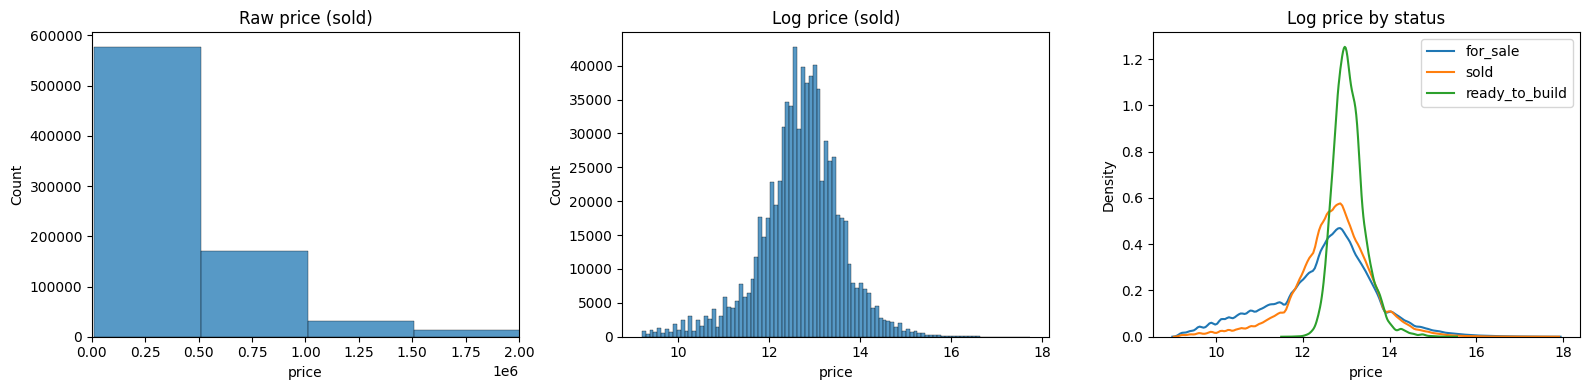

In [25]:
sold = df[df['status'] == 'sold']

print("Skew (raw price):", sold['price'].skew().round(2))
print("Skew (log price):", np.log(sold['price'].dropna()).skew().round(2))
print()
print("Upper tail:")
print(sold['price'].quantile([0.9, 0.95, 0.99, 0.995, 0.999, 0.9999]).round(0))
print()
print(f"sold above $5M:  {(sold['price'] > 5_000_000).sum():,}")
print(f"sold above $10M: {(sold['price'] > 10_000_000).sum():,}")
print(f"sold above $20M: {(sold['price'] > 20_000_000).sum():,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(sold['price'], bins=100, ax=axes[0])
axes[0].set_xlim(0, 2_000_000)
axes[0].set_title('Raw price (sold)')

sns.histplot(np.log(sold['price'].dropna()), bins=100, ax=axes[1])
axes[1].set_title('Log price (sold)')

for s in df['status'].dropna().unique():
    sns.kdeplot(np.log(df.loc[df['status'] == s, 'price'].dropna()), label=s, ax=axes[2])
axes[2].set_title('Log price by status')
axes[2].legend()

plt.tight_layout()
plt.show()

## Target Variable Analysis: `price`

The plots above examine the distribution of our target variable.

**Raw price (sold).** The distribution is severely right-skewed — the overwhelming majority of sales sit below \$500K, with a long thin tail stretching to the multi-million-dollar range. Skew measures **15.17**.

**Log price (sold).** After log transformation the distribution is approximately normal, with skew dropping to **−0.42**. This justifies training on `log(price)` rather than raw dollars: on the raw scale, a \$200K error on a \$3M home would dominate the loss function relative to a \$20K error on a \$200K home, so the model would optimize disproportionately for expensive properties. The log transform makes it optimize for *proportional* accuracy instead. Predictions are exponentiated back to dollars for reporting.

**Log price by status.** The KDE plot shows that `price` measures a different quantity in each status:

| Status | What `price` means |
|---|---|
| `sold` | The transaction price — what a buyer actually paid |
| `for_sale` | The asking price — what a seller hopes to get |
| `ready_to_build` | The builder's advertised base price for a floor plan |

These distributions differ visibly. `for_sale` carries a much heavier left tail, reflecting underpriced and placeholder listings that never transact, while `ready_to_build` forms a narrow spike consistent with standardized builder pricing.

**Decision:** train on `sold` listings only. Combining all three statuses would make the target a blend of three distinct quantities, and the model would learn a blurred average of "what homes cost" and "what sellers ask" rather than what a house actually sells for. This reduces the training set from 2.2M to roughly 812K rows — a worthwhile trade for a coherent target variable.

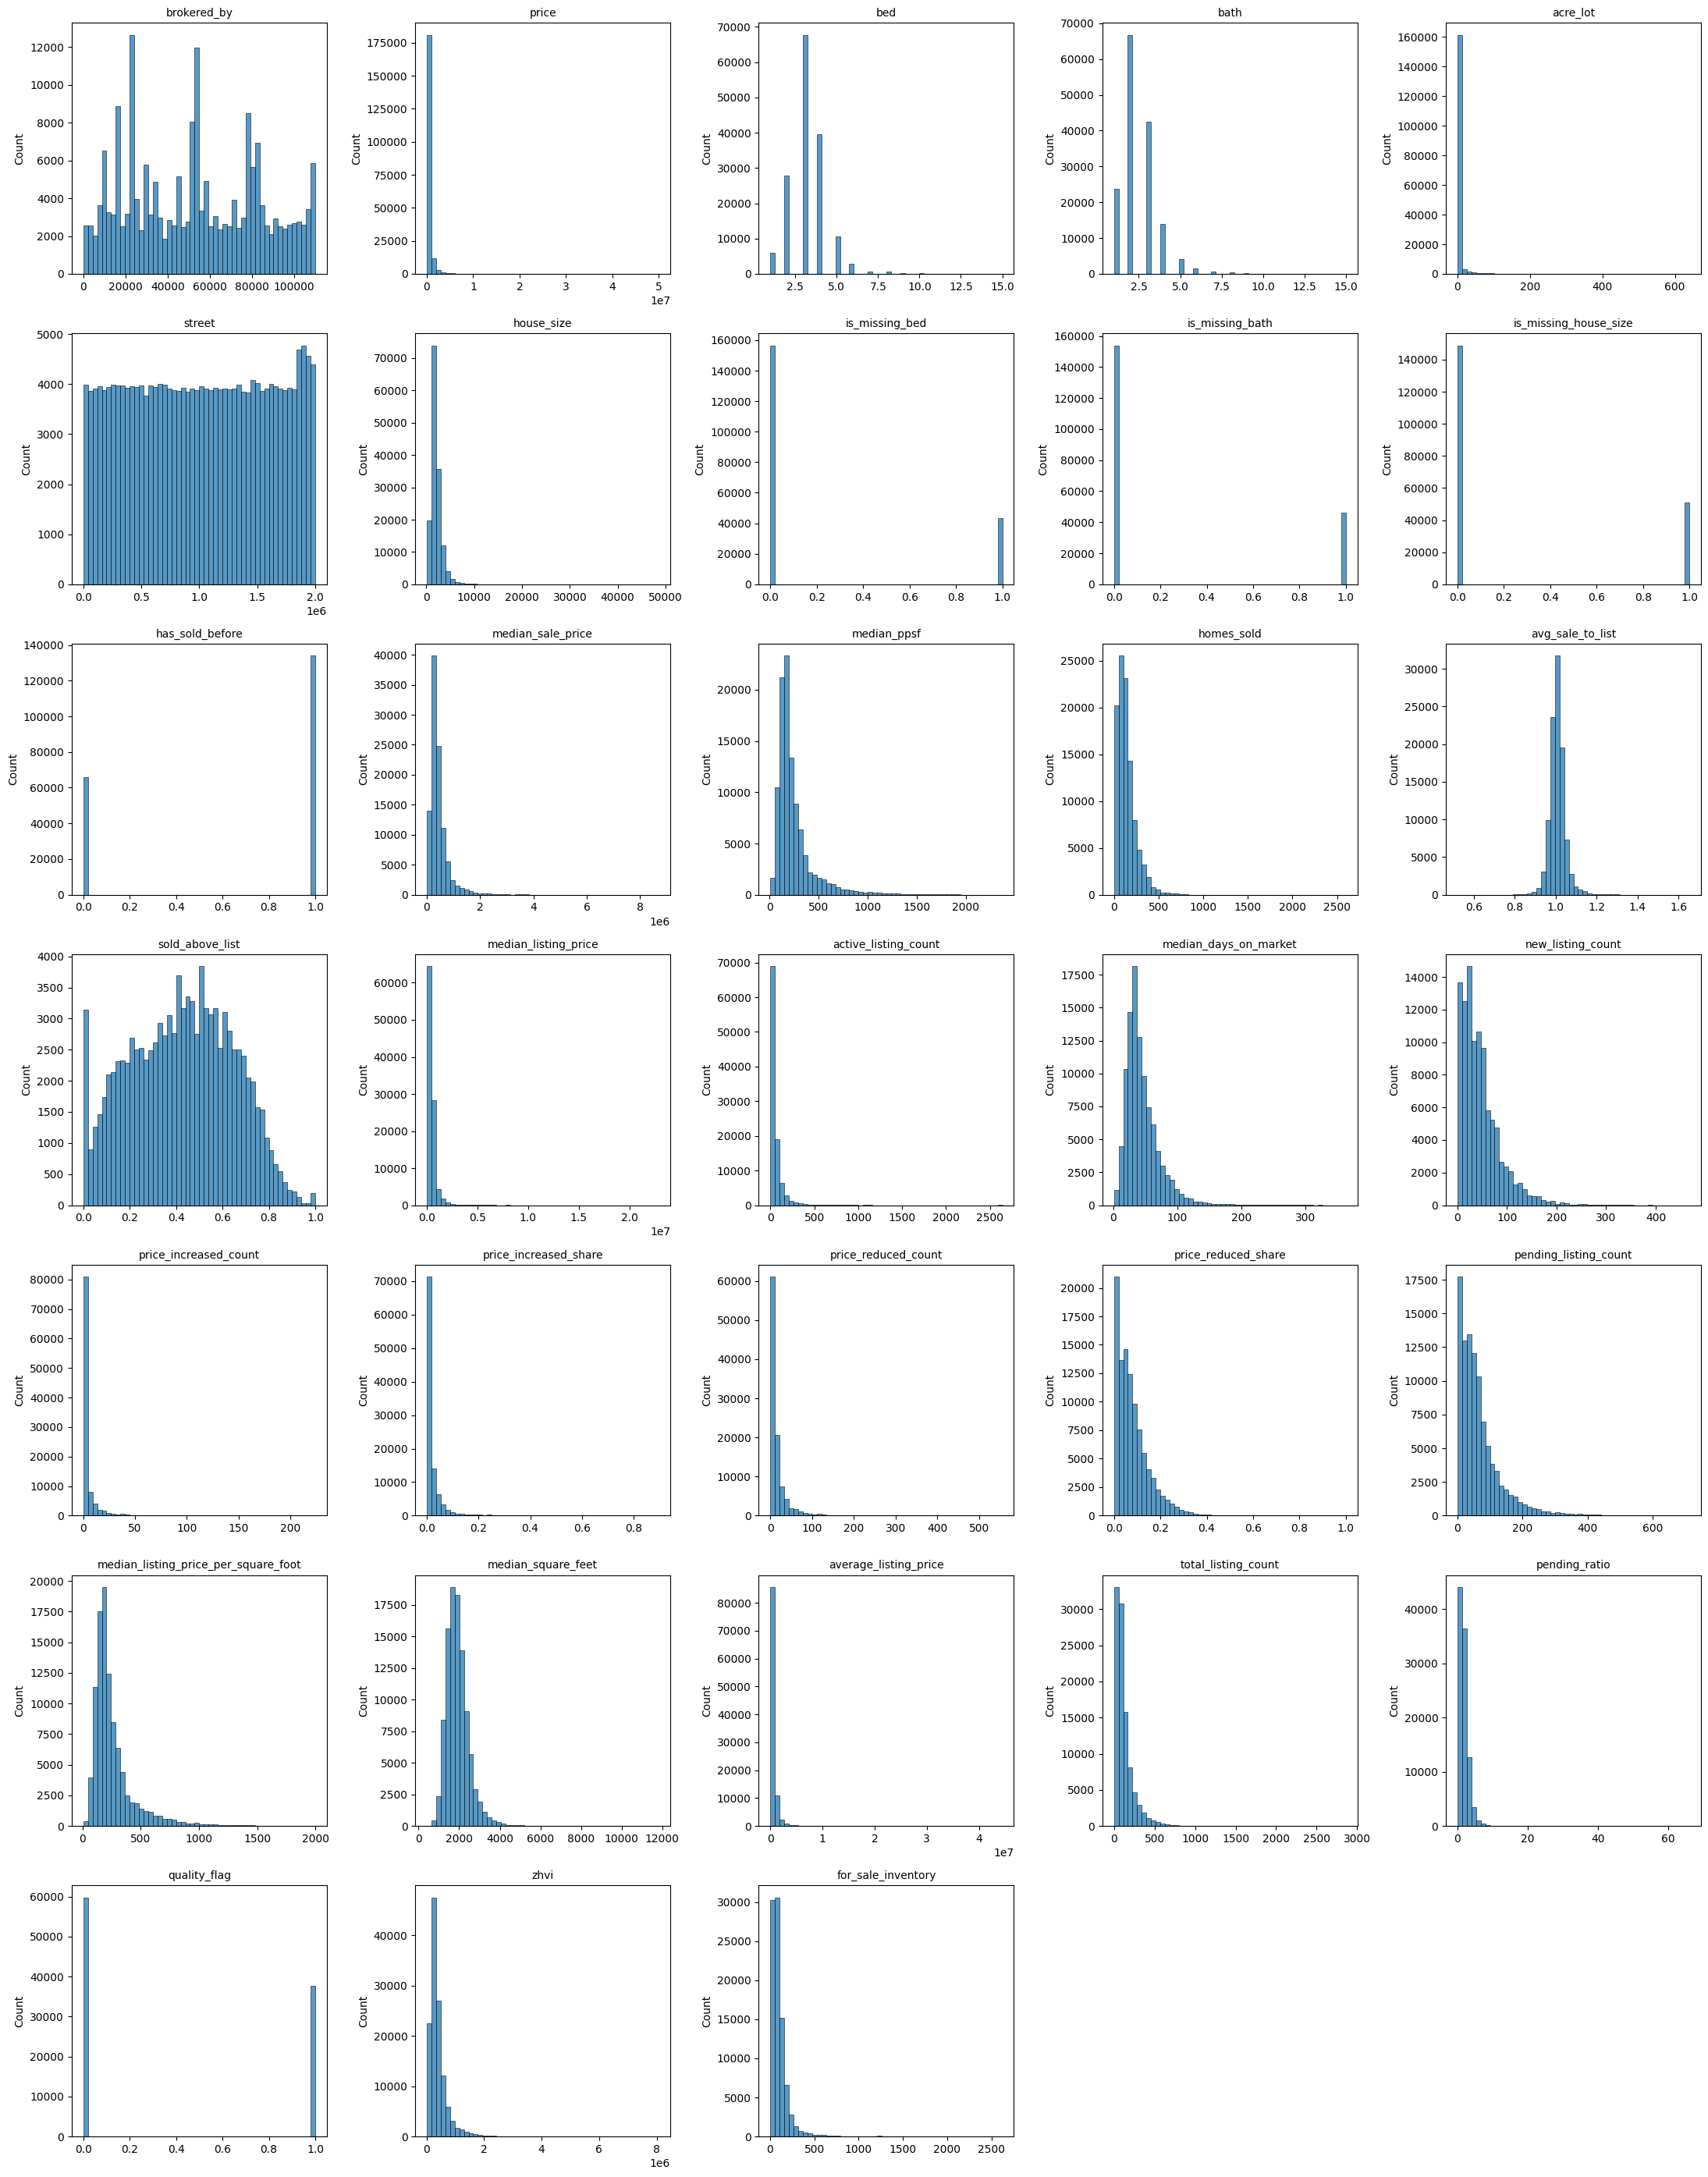

In [26]:
sample = df.sample(200_000, random_state=42)
features = df.select_dtypes(include=['number']).columns.tolist()

n_cols = 5
n_rows = -(-len(features) // n_cols)   # ceiling division

plt.figure(figsize=(22, 4 * n_rows))
for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=sample, x=feature, bins=50)
    plt.title(feature, fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

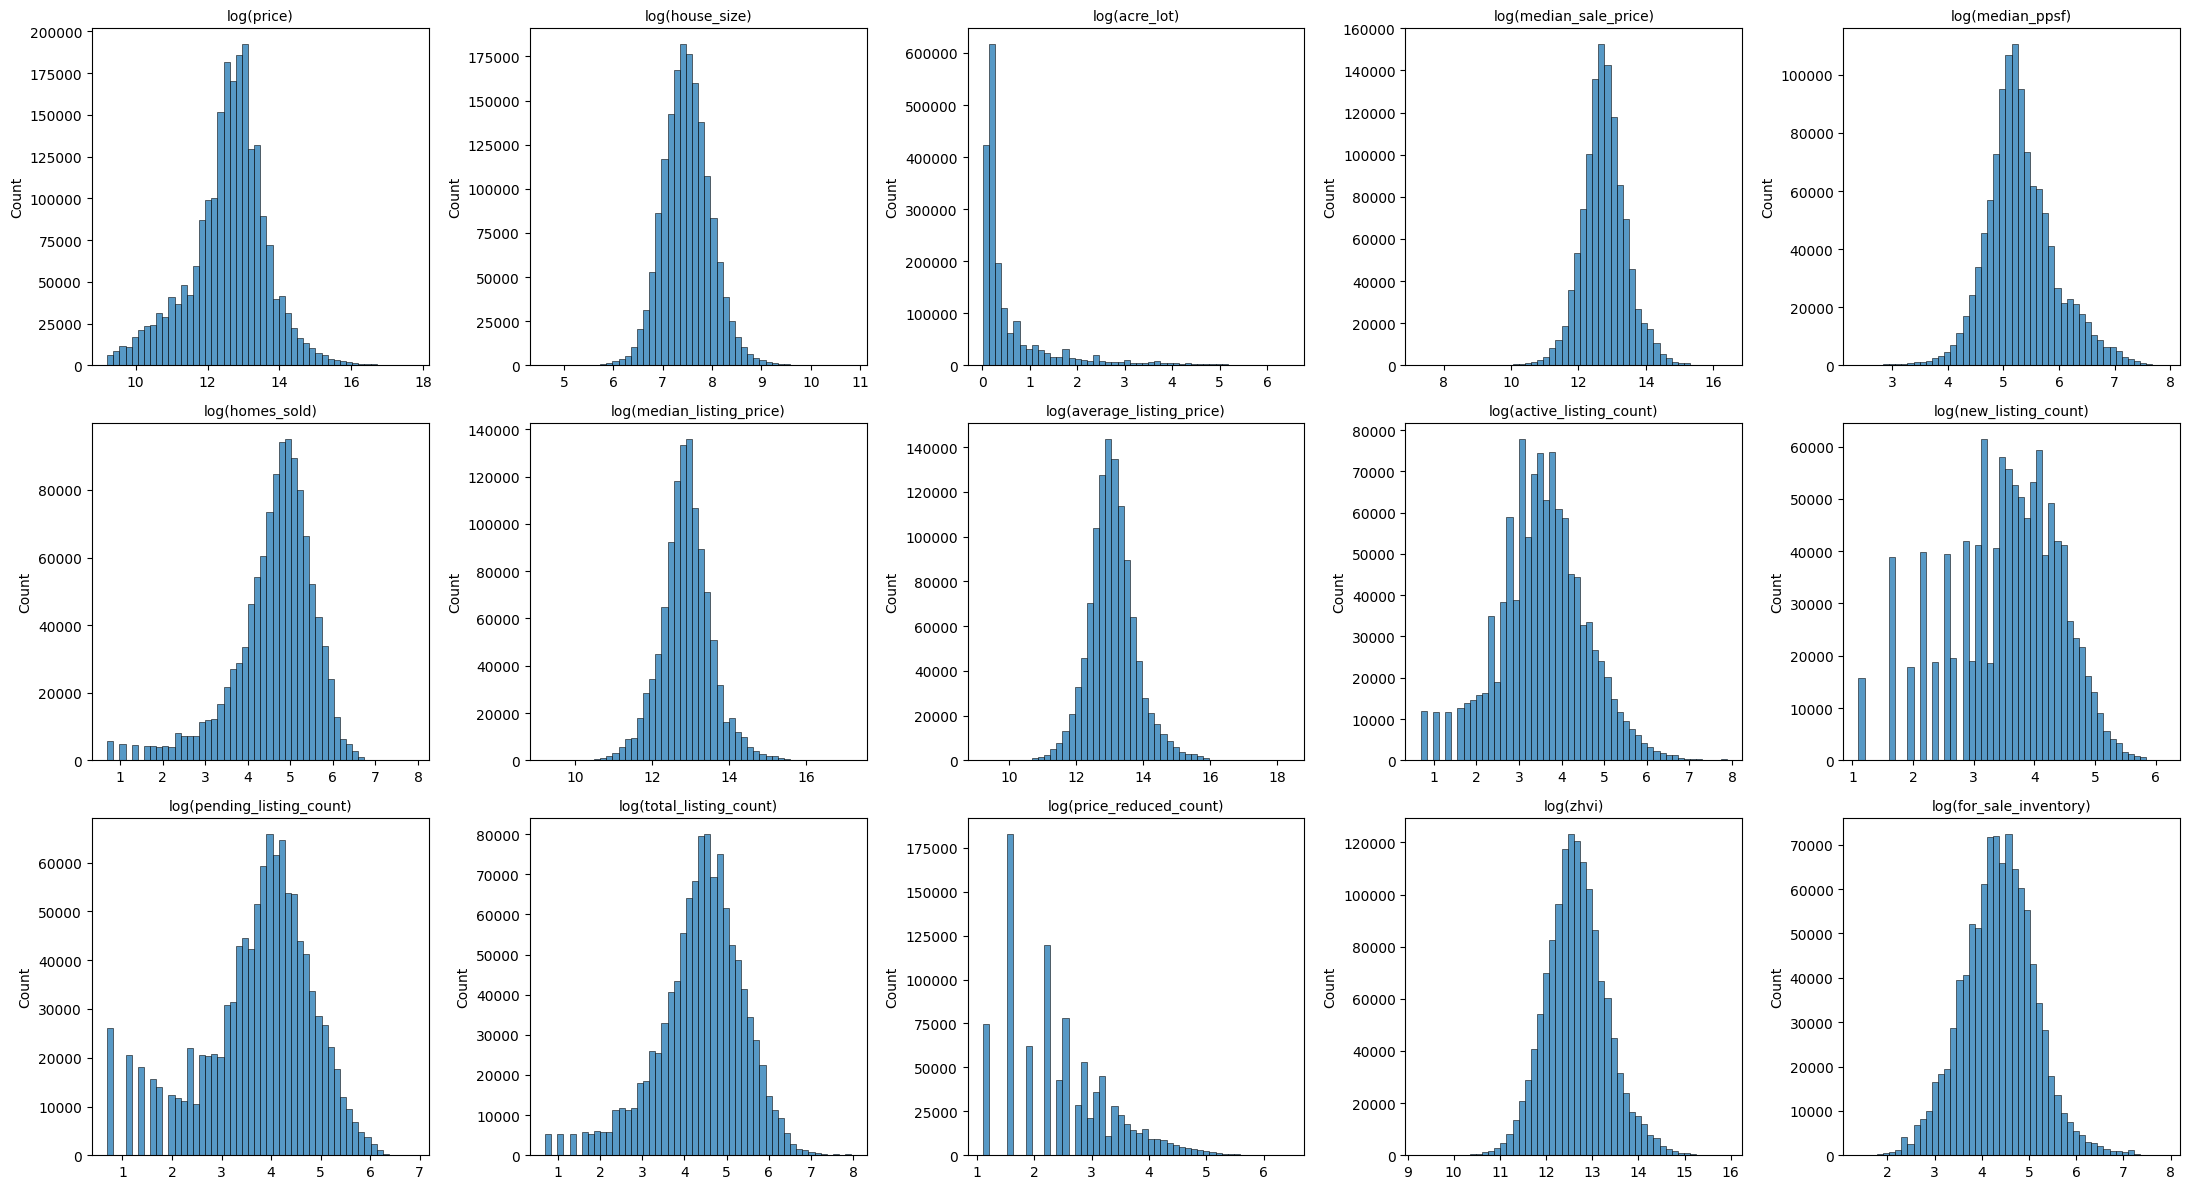

In [27]:
skewed = ['price', 'house_size', 'acre_lot', 'median_sale_price', 'median_ppsf',
          'homes_sold', 'median_listing_price', 'average_listing_price',
          'active_listing_count', 'new_listing_count', 'pending_listing_count',
          'total_listing_count', 'price_reduced_count', 'zhvi', 'for_sale_inventory']

plt.figure(figsize=(22, 4 * -(-len(skewed) // 5)))
for i, feature in enumerate(skewed):
    plt.subplot(-(-len(skewed) // 5), 5, i + 1)
    vals = df[feature].dropna()
    sns.histplot(np.log1p(vals[vals > 0]), bins=50)
    plt.title(f'log({feature})', fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

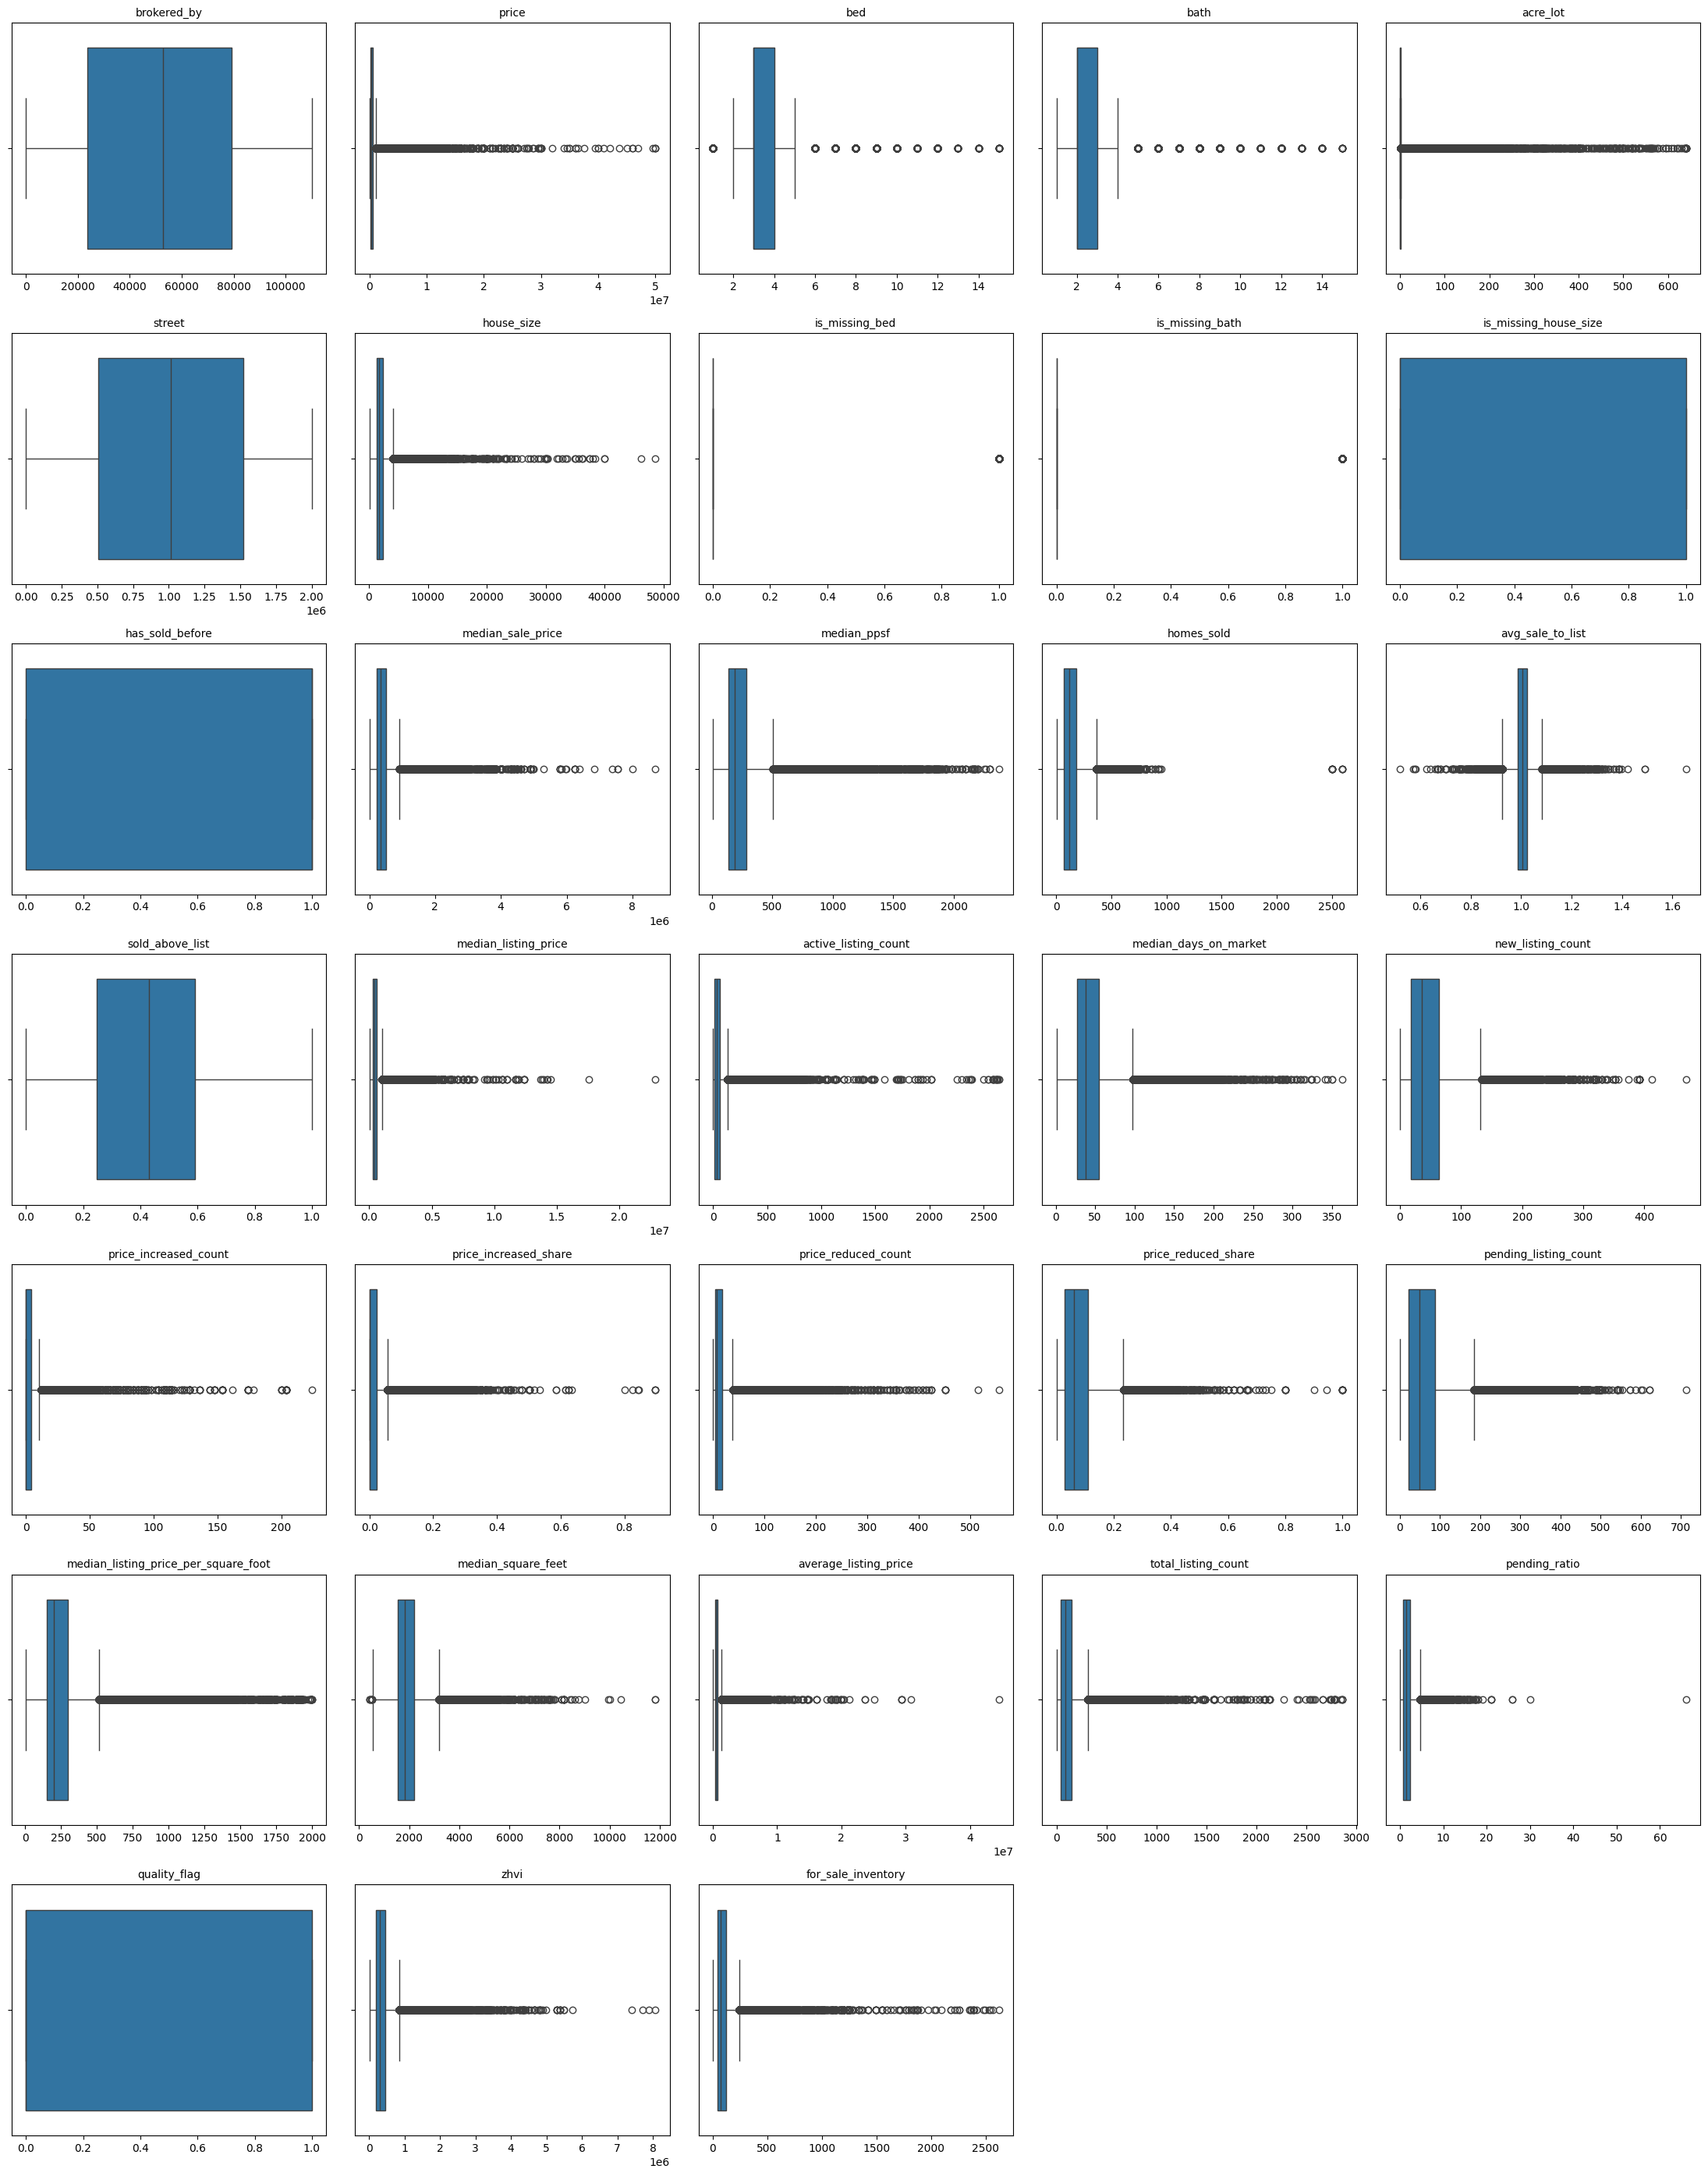

In [28]:
sample = df.sample(200_000, random_state=42)
features = df.select_dtypes(include=['number']).columns.tolist()

n_cols = 5
n_rows = -(-len(features) // n_cols)


plt.figure(figsize=(22, 4 * n_rows))
for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=sample, x=feature)
    plt.title(feature, fontsize=10)
    plt.xlabel('')

plt.tight_layout()
plt.show()

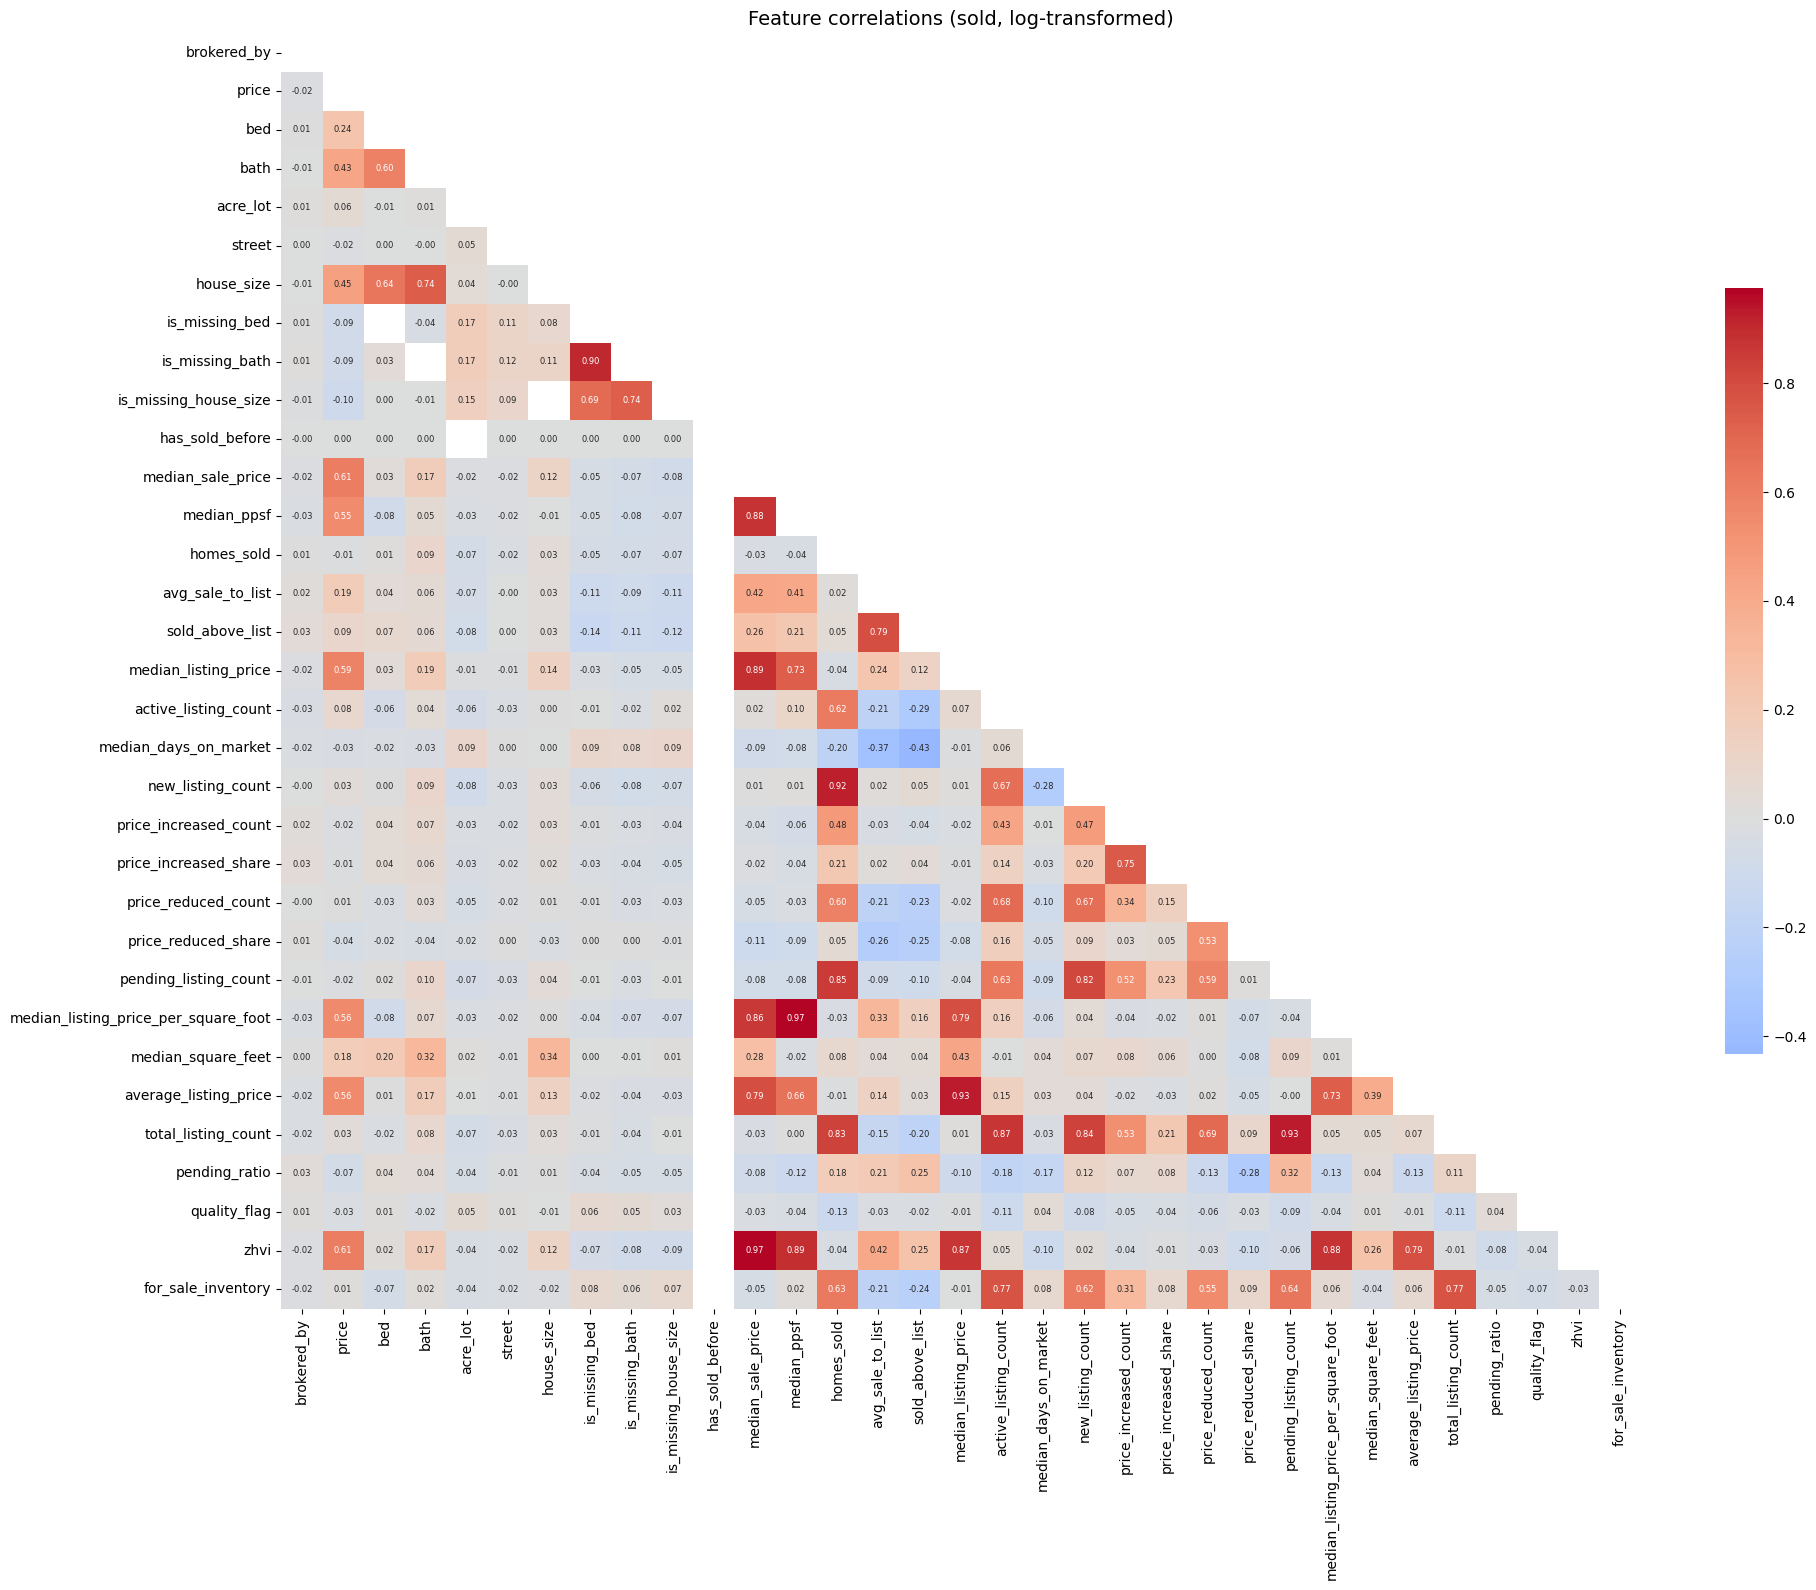

In [29]:
sold_model = df[df['status'] == 'sold']

corr = sold_model.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the redundant upper half

plt.figure(figsize=(20, 16))
sns.heatmap(corr, mask=mask, annot=True, fmt='0.2f', cmap='coolwarm',
            center=0, annot_kws={'size': 6}, cbar_kws={'shrink': 0.6})
plt.title('Feature correlations (sold, log-transformed)', fontsize=14)
plt.tight_layout()
plt.show()

### Feature Correlations

**Market context predicts price better than the property itself.** The strongest correlations with `price` are all merged market features — `median_sale_price` (0.61), `zhvi` (0.61), `median_listing_price` (0.59), `median_listing_price_per_square_foot` (0.56), `median_ppsf` (0.55) — while the property's own attributes rank lower: `house_size` (0.45), `bath` (0.43), `bed` (0.24). Location and market conditions carry more signal than the physical characteristics of the home, which is the empirical justification for the multi-source merge.

**Two redundancy blocks require pruning.** Six features measure zip-level price level and are near-duplicates of each other: `median_ppsf` ↔ `median_listing_price_per_square_foot` (0.97), `median_sale_price` ↔ `zhvi` (0.97), `median_listing_price` ↔ `average_listing_price` (0.93). A second block measures market volume: `total_listing_count` ↔ `pending_listing_count` (0.93), `new_listing_count` ↔ `homes_sold` (0.92), `total_listing_count` ↔ `active_listing_count` (0.87). One or two features from each block is sufficient — the rest add multicollinearity without new information.

**Leakage check passed.** `median_sale_price` (Redfin's concurrent-period zip median, which could theoretically include the sale being predicted) correlates 0.61 with `price` — identical to `zhvi` at 0.61, which is independently derived and cannot contain the target. Contamination would have produced a markedly higher figure.

**Market dynamics are internally coherent**, supporting data quality: `median_days_on_market` correlates −0.43 with `sold_above_list` and −0.37 with `avg_sale_to_list`. Fast markets sell above asking; slow markets do not.

**Two columns flagged for removal.** `has_sold_before` is constant (all `sold` rows have a prior sale date) and returns no correlation. `is_missing_bed` and `is_missing_bath` correlate at 0.90 — when one attribute is missing the other almost always is too, so only one flag is needed.

**`street` and `brokered_by` correlate near zero with every variable** (maximum 0.12 and 0.03), confirming they are arbitrary identifiers with no predictive signal.

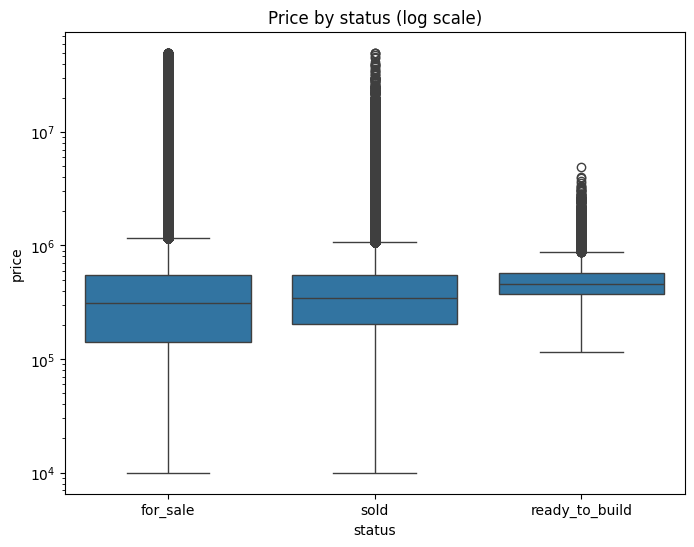

In [30]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='status', y='price')
plt.yscale('log')
plt.title('Price by status (log scale)')
plt.show()

In [31]:
df.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date',
       'is_missing_bed', 'is_missing_bath', 'is_missing_house_size',
       'has_sold_before', 'median_sale_price', 'median_ppsf', 'homes_sold',
       'avg_sale_to_list', 'sold_above_list', 'parent_metro_region',
       'median_listing_price', 'active_listing_count', 'median_days_on_market',
       'new_listing_count', 'price_increased_count', 'price_increased_share',
       'price_reduced_count', 'price_reduced_share', 'pending_listing_count',
       'median_listing_price_per_square_foot', 'median_square_feet',
       'average_listing_price', 'total_listing_count', 'pending_ratio',
       'quality_flag', 'zhvi', 'for_sale_inventory'],
      dtype='object')

### **Data Preparation for Modeling**

In [32]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- feature engineering (sold listings only) ---
model_df = df[df['status'] == 'sold'].copy()

# broker_cat: bounded categorical from the raw broker ID
top_brokers = model_df['brokered_by'].value_counts().nlargest(200).index
model_df['broker_cat'] = np.where(
    model_df['brokered_by'].isin(top_brokers),
    model_df['brokered_by'].astype('string'),
    'other'
)
model_df['broker_cat'] = model_df['broker_cat'].fillna('missing').astype('category')

# log transforms -> new columns, so the cell is safe to re-run
for col in ['house_size', 'zhvi', 'median_ppsf']:
    model_df[f'log_{col}'] = np.log(model_df[col].where(model_df[col] > 0))

for col in ['acre_lot', 'active_listing_count', 'homes_sold', 'median_days_on_market']:
    model_df[f'log_{col}'] = np.log1p(model_df[col].where(model_df[col] >= 0))

# target + temporal
model_df['log_price'] = np.log(model_df['price'].where(model_df['price'] > 0))
model_df['sale_month'] = model_df['prev_sold_date'].dt.month

# categoricals need a consistent dtype for downstream models
for col in ['state', 'parent_metro_region']:
    model_df[col] = model_df[col].astype('category')

# --- feature set ---
target = 'log_price'
features = [
    # property
    'log_house_size', 'bath', 'bed', 'log_acre_lot',
    # market price level
    'log_zhvi', 'log_median_ppsf',
    # market activity
    'log_active_listing_count', 'log_homes_sold',
    # market temperature
    'avg_sale_to_list', 'sold_above_list', 'log_median_days_on_market', 'price_reduced_share',
    # missingness signal
    'is_missing_house_size', 'is_missing_bed',
    # categorical
    'state', 'parent_metro_region', 'broker_cat', 'quality_flag',
    # temporal
    'sale_month',
]

# drop rows with no target -- can't train or score on those
model_df = model_df[model_df[target].notna()]

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print(f"X:       {X.shape}")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nMissing per feature:\n{X.isnull().mean().mul(100).round(1).sort_values(ascending=False).to_string()}")

X:       (808744, 19)
X_train: (646995, 19)
X_test:  (161749, 19)

Missing per feature:
log_acre_lot                 13.5
log_house_size               12.5
bath                          9.3
bed                           8.3
avg_sale_to_list              5.8
log_homes_sold                5.3
log_median_ppsf               5.3
sold_above_list               5.3
parent_metro_region           5.3
log_zhvi                      0.7
log_active_listing_count      0.2
log_median_days_on_market     0.2
price_reduced_share           0.2
quality_flag                  0.2
is_missing_house_size         0.0
state                         0.0
is_missing_bed                0.0
broker_cat                    0.0
sale_month                    0.0


### **Model Building**

#### **Simple Linear Regression - `Price` vs `house_size`**

In [33]:
ind_vars1 = ['log_house_size']

# drop rows where the predictor is missing, in both train and test
tr_mask = X_train[ind_vars1].notna().all(axis=1)
te_mask = X_test[ind_vars1].notna().all(axis=1)

X_tr1, y_tr1 = X_train.loc[tr_mask, ind_vars1], y_train[tr_mask]
X_te1, y_te1 = X_test.loc[te_mask, ind_vars1], y_test[te_mask]

print(f"Train: {len(X_tr1):,} of {len(X_train):,}  ({tr_mask.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te1):,} of {len(X_test):,}  ({te_mask.mean()*100:.1f}% retained)\n")

lin_reg1 = LinearRegression()
lin_reg1.fit(X_tr1, y_tr1)

preds1 = lin_reg1.predict(X_te1)

Train: 566,187 of 646,995  (87.5% retained)
Test:  141,703 of 161,749  (87.6% retained)



In [34]:
# printing the linear regression coefficients
print(
    "Slope:", lin_reg1.coef_,
    "Intercept:", lin_reg1.intercept_,
)

Slope: [0.86669069] Intercept: 6.356910957656541


In [35]:
print(
    "log(price) =",
    "(", lin_reg1.coef_[0], ")", "*", ind_vars1[0],
    "+", lin_reg1.intercept_,
)

log(price) = ( 0.8666906865668096 ) * log_house_size + 6.356910957656541


`price ≈ 576.5 × house_size^0.8667`

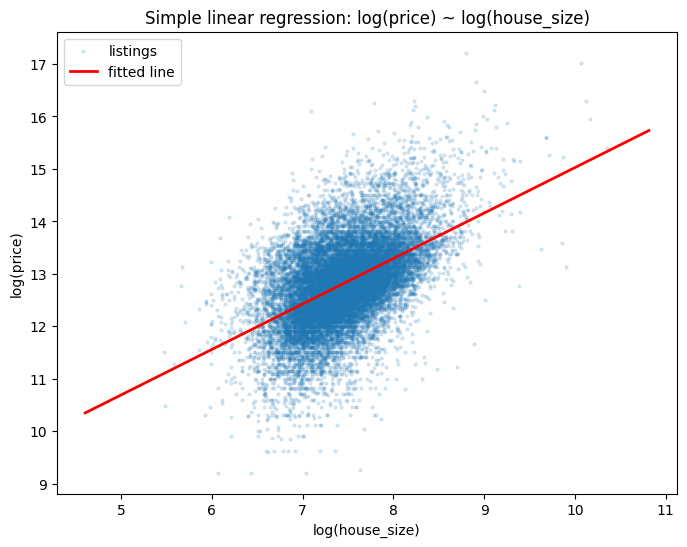

In [36]:
fitted_values1 = lin_reg1.predict(X_tr1)

# sample for a readable scatter
samp = np.random.default_rng(42).choice(len(X_tr1), size=20_000, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(X_tr1.iloc[samp, 0], y_tr1.iloc[samp], s=4, alpha=0.15, label='listings')

# sort by x so the line draws cleanly
order = np.argsort(X_tr1.iloc[:, 0].values)
plt.plot(X_tr1.iloc[order, 0], fitted_values1[order], color='red', linewidth=2, label='fitted line')

plt.xlabel('log(house_size)')
plt.ylabel('log(price)')
plt.title('Simple linear regression: log(price) ~ log(house_size)')
plt.legend()
plt.show()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

preds1 = lin_reg1.predict(X_te1)

# in log space (what the model actually optimized)
print("--- log space ---")
print(f"R²:   {r2_score(y_te1, preds1):.4f}")
print(f"MAE:  {mean_absolute_error(y_te1, preds1):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_te1, preds1)):.4f}")

# back in dollars (what a reader understands)
actual_d = np.exp(y_te1)
pred_d = np.exp(preds1)

print("\n--- dollars ---")
print(f"MAE:   ${mean_absolute_error(actual_d, pred_d):,.0f}")
print(f"RMSE:  ${np.sqrt(mean_squared_error(actual_d, pred_d)):,.0f}")
print(f"MedAE: ${np.median(np.abs(actual_d - pred_d)):,.0f}")

# median absolute percentage error -- most intuitive for a price model
mape = np.median(np.abs(actual_d - pred_d) / actual_d) * 100
print(f"Median APE: {mape:.1f}%")

# train R² too, to check for over/underfitting
print(f"\nTrain R²: {r2_score(y_tr1, lin_reg1.predict(X_tr1)):.4f}")

--- log space ---
R²:   0.2512
MAE:  0.5135
RMSE: 0.6758

--- dollars ---
MAE:   $254,045
RMSE:  $641,035
MedAE: $131,982
Median APE: 39.4%

Train R²: 0.2534


### Baseline Model: `log_price ~ log_house_size`

| Metric | Value |
|---|---|
| R² (test) | 0.2512 |
| R² (train) | 0.2534 |
| MAE | \$254,045 |
| Median AE | \$131,982 |
| RMSE | \$641,035 |
| Median APE | 39.4% |

House size alone explains roughly **25% of the variation in sale price**, leaving three quarters unexplained. The model is typically off by **39.4%** of a home's actual value.

Train and test R² are nearly identical (0.2534 vs 0.2512), confirming the model **underfits** rather than overfits — a single straight line cannot memorize 566,187 observations. The limitation is missing information, not model complexity, which means adding features should yield real improvement.

The gap between mean error (\$254,045) and median error (\$131,982) reflects the luxury tail: a small number of large misses on expensive homes inflate the average. RMSE of \$641,035 confirms this, since squared error penalizes those cases most heavily. Median absolute error is the more representative measure of typical performance.

These figures establish the benchmark all subsequent models must beat: **R² of 0.25 and median APE of 39.4%**.

#### **Simple Linear Regression - `Price` vs `log_zhvi`**

In [38]:
ind_vars2 = ['log_zhvi']

# drop rows where the predictor is missing, in both train and test
tr_mask2 = X_train[ind_vars2].notna().all(axis=1)
te_mask2 = X_test[ind_vars2].notna().all(axis=1)

X_tr2, y_tr2 = X_train.loc[tr_mask2, ind_vars2], y_train[tr_mask2]
X_te2, y_te2 = X_test.loc[te_mask2, ind_vars2], y_test[te_mask2]

print(f"Train: {len(X_tr2):,} of {len(X_train):,}  ({tr_mask2.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te2):,} of {len(X_test):,}  ({te_mask2.mean()*100:.1f}% retained)\n")

lin_reg2 = LinearRegression()
lin_reg2.fit(X_tr2, y_tr2)

preds2 = lin_reg2.predict(X_te2)

Train: 642,590 of 646,995  (99.3% retained)
Test:  160,668 of 161,749  (99.3% retained)



In [39]:
print(
    "Slope:", lin_reg2.coef_,
    "Intercept:", lin_reg2.intercept_,
)

Slope: [1.01555439] Intercept: -0.34042632461157396


In [40]:
print(
    "log(price) =",
    "(", lin_reg2.coef_[0], ")", "*", ind_vars2[0],
    "+", lin_reg2.intercept_,
)

log(price) = ( 1.015554392165461 ) * log_zhvi + -0.34042632461157396


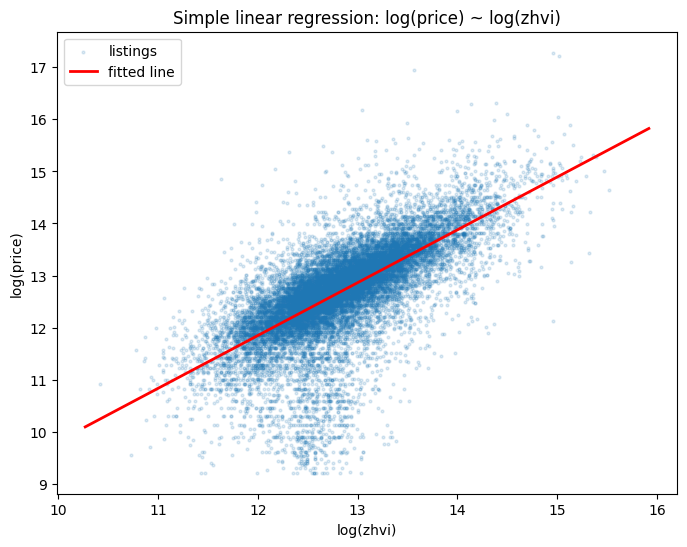

In [41]:
fitted_values2 = lin_reg2.predict(X_tr2)

# sample for a readable scatter
samp = np.random.default_rng(42).choice(len(X_tr2), size=20_000, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(X_tr2.iloc[samp, 0], y_tr2.iloc[samp], s=4, alpha=0.15, label='listings')

# sort by x so the line draws cleanly
order = np.argsort(X_tr2.iloc[:, 0].values)
plt.plot(X_tr2.iloc[order, 0], fitted_values2[order], color='red', linewidth=2, label='fitted line')

plt.xlabel('log(zhvi)')
plt.ylabel('log(price)')
plt.title('Simple linear regression: log(price) ~ log(zhvi)')
plt.legend()
plt.show()

In [42]:
# --- metrics ---
print(f"R² (test):  {r2_score(y_te2, preds2):.4f}")
print(f"R² (train): {r2_score(y_tr2, lin_reg2.predict(X_tr2)):.4f}")

actual_d2 = np.exp(y_te2)
pred_d2 = np.exp(preds2)

print(f"\nMAE:        ${mean_absolute_error(actual_d2, pred_d2):,.0f}")
print(f"MedAE:      ${np.median(np.abs(actual_d2 - pred_d2)):,.0f}")
print(f"RMSE:       ${np.sqrt(mean_squared_error(actual_d2, pred_d2)):,.0f}")
print(f"Median APE: {np.median(np.abs(actual_d2 - pred_d2) / actual_d2) * 100:.1f}%")

print(f"\nSlope:      {lin_reg2.coef_[0]:.4f}")
print(f"Intercept:  {lin_reg2.intercept_:.4f}")

R² (test):  0.4804
R² (train): 0.4811

MAE:        $190,876
MedAE:      $91,443
RMSE:       $547,383
Median APE: 26.9%

Slope:      1.0156
Intercept:  -0.3404


### Simple Linear Regression: `log_price ~ log_zhvi`

Fitted equation:

$$\log(\text{price}) = 1.0156 \times \log(\text{zhvi}) - 0.3404$$

| Metric | `log_house_size` | `log_zhvi` | Change |
|---|---|---|---|
| R² (test) | 0.2512 | **0.4804** | +91% |
| R² (train) | 0.2534 | 0.4811 | — |
| MAE | \$254,045 | **\$190,876** | −25% |
| Median AE | \$131,982 | **\$91,443** | −31% |
| RMSE | \$641,035 | **\$547,383** | −15% |
| Median APE | 39.4% | **26.9%** | −12.5 pts |

**Location outperforms the property itself.** A single market feature — the ZIP-level Zillow Home Value Index at the time of sale — explains 48% of price variation, nearly double the 25% explained by the home's square footage. Median error falls from roughly \$132K to \$91K, and typical percentage error from 39.4% to 26.9%.

This is the empirical justification for the multi-source merge: geographic market context carries more predictive signal than the physical characteristics of the house.

**The coefficient has a clean economic interpretation.** With both variables log-transformed, the slope of **1.0156** is an elasticity of approximately 1.0 — a ZIP that is 1% more expensive contains homes that sell for about 1% more. Price tracks local market level almost exactly proportionally.

This contrasts with `house_size`, whose elasticity of 0.87 indicated *diminishing returns* — larger homes command a lower price per square foot. Market level shows no such attenuation.

**The model still underfits.** Train and test R² are effectively identical (0.4811 vs 0.4804), indicating no overfitting and substantial remaining headroom. Roughly half the variance in price remains unexplained by market level alone — the gap that property characteristics and additional market features are expected to close.

**Coverage note:** `zhvi` is missing in only 0.7% of sold listings, compared with 12.8% for `house_size`. The two models therefore train on slightly different samples, though the magnitude of the difference in performance far exceeds what sample variation could account for.

## **Simple Linear Regression - `median_ppsf` vs `Price`**

In [43]:
ind_vars3 = ['log_median_ppsf']

# drop rows where the predictor is missing, in both train and test
tr_mask3 = X_train[ind_vars3].notna().all(axis=1)
te_mask3 = X_test[ind_vars3].notna().all(axis=1)

X_tr3, y_tr3 = X_train.loc[tr_mask3, ind_vars3], y_train[tr_mask3]
X_te3, y_te3 = X_test.loc[te_mask3, ind_vars3], y_test[te_mask3]

print(f"Train: {len(X_tr3):,} of {len(X_train):,}  ({tr_mask3.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te3):,} of {len(X_test):,}  ({te_mask3.mean()*100:.1f}% retained)\n")

lin_reg3 = LinearRegression()
lin_reg3.fit(X_tr3, y_tr3)

preds3 = lin_reg3.predict(X_te3)

Train: 612,499 of 646,995  (94.7% retained)
Test:  153,351 of 161,749  (94.8% retained)



In [44]:
print(
    "Slope:", lin_reg3.coef_,
    "Intercept:", lin_reg3.intercept_,
)

Slope: [0.98377797] Intercept: 7.373295483537716


In [45]:
print(
    "log(price) =",
    "(", lin_reg3.coef_[0], ")", "*", ind_vars3[0],
    "+", lin_reg3.intercept_,
)

log(price) = ( 0.9837779675252217 ) * log_median_ppsf + 7.373295483537716


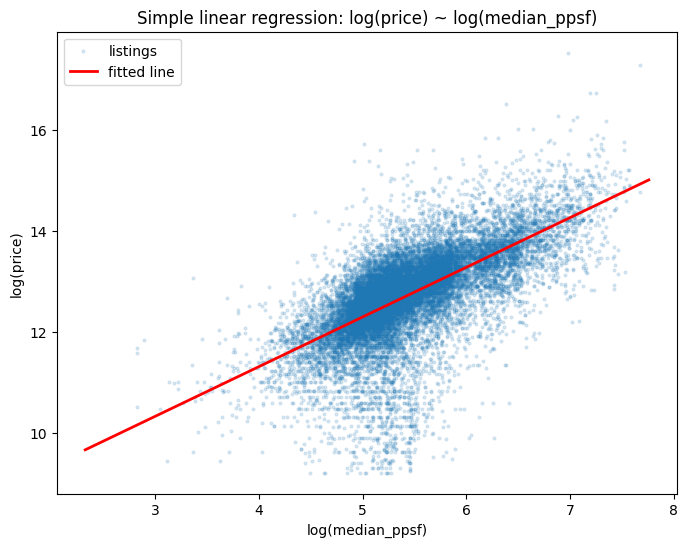

In [46]:
fitted_values3 = lin_reg3.predict(X_tr3)

# sample for a readable scatter
samp = np.random.default_rng(42).choice(len(X_tr3), size=20_000, replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(X_tr3.iloc[samp, 0], y_tr3.iloc[samp], s=4, alpha=0.15, label='listings')

# sort by x so the line draws cleanly
order = np.argsort(X_tr3.iloc[:, 0].values)
plt.plot(X_tr3.iloc[order, 0], fitted_values3[order], color='red', linewidth=2, label='fitted line')

plt.xlabel('log(median_ppsf)')
plt.ylabel('log(price)')
plt.title('Simple linear regression: log(price) ~ log(median_ppsf)')
plt.legend()
plt.show()

In [47]:
# --- metrics ---
print(f"R² (test):  {r2_score(y_te3, preds3):.4f}")
print(f"R² (train): {r2_score(y_tr3, lin_reg3.predict(X_tr3)):.4f}")

actual_d3 = np.exp(y_te3)
pred_d3 = np.exp(preds3)

print(f"\nMAE:        ${mean_absolute_error(actual_d3, pred_d3):,.0f}")
print(f"MedAE:      ${np.median(np.abs(actual_d3 - pred_d3)):,.0f}")
print(f"RMSE:       ${np.sqrt(mean_squared_error(actual_d3, pred_d3)):,.0f}")
print(f"Median APE: {np.median(np.abs(actual_d3 - pred_d3) / actual_d3) * 100:.1f}%")

print(f"\nSlope:      {lin_reg3.coef_[0]:.4f}")
print(f"Intercept:  {lin_reg3.intercept_:.4f}")

R² (test):  0.4247
R² (train): 0.4226

MAE:        $211,294
MedAE:      $102,685
RMSE:       $588,751
Median APE: 29.9%

Slope:      0.9838
Intercept:  7.3733


In [48]:
feats_a = ['log_zhvi', 'log_house_size']
tr_m = X_train[feats_a].notna().all(axis=1)
te_m = X_test[feats_a].notna().all(axis=1)

lin_reg_a = LinearRegression().fit(X_train.loc[tr_m, feats_a], y_train[tr_m])
preds_a = lin_reg_a.predict(X_test.loc[te_m, feats_a])

actual_a = np.exp(y_test[te_m])
pred_a = np.exp(preds_a)

print(f"R² (test):  {r2_score(y_test[te_m], preds_a):.4f}")
print(f"R² (train): {r2_score(y_train[tr_m], lin_reg_a.predict(X_train.loc[tr_m, feats_a])):.4f}")
print(f"MAE:        ${mean_absolute_error(actual_a, pred_a):,.0f}")
print(f"MedAE:      ${np.median(np.abs(actual_a - pred_a)):,.0f}")
print(f"RMSE:       ${np.sqrt(mean_squared_error(actual_a, pred_a)):,.0f}")
print(f"Median APE: {np.median(np.abs(actual_a - pred_a) / actual_a) * 100:.1f}%")

R² (test):  0.7744
R² (train): 0.7767
MAE:        $134,407
MedAE:      $64,626
RMSE:       $419,771
Median APE: 18.8%


In [49]:
ind_vars6 = ['log_zhvi', 'log_house_size', 'bed', 'bath', 'log_acre_lot']


In [50]:
tr_mask6 = X_train[ind_vars6].notna().all(axis=1)
te_mask6 = X_test[ind_vars6].notna().all(axis=1)

In [51]:
X_tr6, y_tr6 = X_train.loc[tr_mask6, ind_vars6], y_train[tr_mask6]
X_te6, y_te6 = X_test.loc[te_mask6, ind_vars6], y_test[te_mask6]

print(f"Train: {len(X_tr6):,} of {len(X_train):,}  ({tr_mask6.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te6):,} of {len(X_test):,}  ({te_mask6.mean()*100:.1f}% retained)")


Train: 484,001 of 646,995  (74.8% retained)
Test:  121,198 of 161,749  (74.9% retained)


In [52]:
lin_reg6 = LinearRegression().fit(X_tr6, y_tr6)
preds6 = lin_reg6.predict(X_te6)

In [53]:
print("\nCoefficients:")
for name, coef in zip(ind_vars6, lin_reg6.coef_):
    print(f"  {name:<16} {coef:.4f}")
print(f"  {'intercept':<16} {lin_reg6.intercept_:.4f}")

print(f"\nR² (test):  {r2_score(y_te6, preds6):.4f}")
print(f"R² (train): {r2_score(y_tr6, lin_reg6.predict(X_tr6)):.4f}")


Coefficients:
  log_zhvi         0.9131
  log_house_size   0.5109
  bed              0.0129
  bath             0.0803
  log_acre_lot     0.0959
  intercept        -2.9866

R² (test):  0.8151
R² (train): 0.8165


In [54]:
actual_d6 = np.exp(y_te6)
pred_d6 = np.exp(preds6)
print(f"\nMAE:        ${mean_absolute_error(actual_d6, pred_d6):,.0f}")
print(f"MedAE:      ${np.median(np.abs(actual_d6 - pred_d6)):,.0f}")
print(f"RMSE:       ${np.sqrt(mean_squared_error(actual_d6, pred_d6)):,.0f}")
print(f"Median APE: {np.median(np.abs(actual_d6 - pred_d6) / actual_d6) * 100:.1f}%")


MAE:        $125,140
MedAE:      $61,303
RMSE:       $380,989
Median APE: 17.6%


In [55]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# numeric predictors only -- VIF isn't meaningful for raw categoricals
vif_candidates = [
    'log_house_size', 'bath', 'bed', 'log_acre_lot',
    'log_zhvi', 'log_median_ppsf',
    'log_active_listing_count', 'log_homes_sold',
    'avg_sale_to_list', 'sold_above_list',
    'log_median_days_on_market', 'price_reduced_share',
    'sale_month'
]

# VIF needs complete rows -- listwise drop just for this diagnostic
vif_df = X_train[vif_candidates].dropna()
print(f"Rows used for VIF: {len(vif_df):,} of {len(X_train):,} ({len(vif_df)/len(X_train)*100:.1f}%)")

vif_X = add_constant(vif_df)

vif_results = pd.DataFrame({
    'feature': vif_X.columns,
    'VIF': [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]
})
vif_results = vif_results[vif_results['feature'] != 'const'].sort_values('VIF', ascending=False)
print(vif_results.to_string(index=False))

Rows used for VIF: 458,635 of 646,995 (70.9%)
                  feature      VIF
                 log_zhvi 9.181369
          log_median_ppsf 8.899688
 log_active_listing_count 4.277361
           log_homes_sold 4.134445
          sold_above_list 3.246207
           log_house_size 3.208087
         avg_sale_to_list 3.128265
                     bath 2.536212
                      bed 1.971612
log_median_days_on_market 1.614163
      price_reduced_share 1.239798
               sale_month 1.151721
             log_acre_lot 1.116097


In [56]:
ind_vars7 = ['log_zhvi', 'log_house_size', 'bed', 'bath', 'log_acre_lot', 'log_active_listing_count', 'log_homes_sold', 'sold_above_list', 'avg_sale_to_list', 'log_median_days_on_market', 'price_reduced_share']


In [57]:
tr_mask7 = X_train[ind_vars7].notna().all(axis=1)
te_mask7 = X_test[ind_vars7].notna().all(axis=1)

In [58]:
X_tr7, y_tr7 = X_train.loc[tr_mask7, ind_vars7], y_train[tr_mask7]
X_te7, y_te7 = X_test.loc[te_mask7, ind_vars7], y_test[te_mask7]

In [59]:
print(f"Train: {len(X_tr7):,} of {len(X_train):,}  ({tr_mask7.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te7):,} of {len(X_test):,}  ({te_mask7.mean()*100:.1f}% retained)")

Train: 458,676 of 646,995  (70.9% retained)
Test:  115,007 of 161,749  (71.1% retained)


In [60]:
lin_reg7 = LinearRegression().fit(X_tr7, y_tr7)
preds7 = lin_reg7.predict(X_te7)

print("\nCoefficients:")
for name, coef in zip(ind_vars7, lin_reg7.coef_):
    print(f"  {name:<26} {coef:.4f}")
print(f"  {'intercept':<26} {lin_reg7.intercept_:.4f}")

print(f"\nR² (test):  {r2_score(y_te7, preds7):.4f}")
print(f"R² (train): {r2_score(y_tr7, lin_reg7.predict(X_tr7)):.4f}")


Coefficients:
  log_zhvi                   0.9096
  log_house_size             0.5095
  bed                        0.0148
  bath                       0.0765
  log_acre_lot               0.0825
  log_active_listing_count   0.0090
  log_homes_sold             -0.0056
  sold_above_list            -0.0342
  avg_sale_to_list           0.2412
  log_median_days_on_market  -0.0158
  price_reduced_share        0.2919
  intercept                  -3.1170

R² (test):  0.8195
R² (train): 0.8210


In [61]:
actual_d7 = np.exp(y_te7)
pred_d7 = np.exp(preds7)
print(f"\nMAE:        ${mean_absolute_error(actual_d7, pred_d7):,.0f}")
print(f"MedAE:      ${np.median(np.abs(actual_d7 - pred_d7)):,.0f}")
print(f"RMSE:       ${np.sqrt(mean_squared_error(actual_d7, pred_d7)):,.0f}")
print(f"Median APE: {np.median(np.abs(actual_d7 - pred_d7) / actual_d7) * 100:.1f}%")


MAE:        $126,365
MedAE:      $61,754
RMSE:       $387,555
Median APE: 17.3%


In [62]:
 summary = pd.DataFrame({
    'A: zhvi + house_size': [
        r2_score(y_test[te_m], preds_a),
        r2_score(y_train[tr_m], lin_reg_a.predict(X_train.loc[tr_m, feats_a])),
        mean_absolute_error(actual_a, pred_a),
        np.median(np.abs(actual_a - pred_a)),
        np.sqrt(mean_squared_error(actual_a, pred_a)),
        np.median(np.abs(actual_a - pred_a) / actual_a) * 100,
    ],
    'B: + bed/bath/acre_lot': [
        r2_score(y_te6, preds6),
        r2_score(y_tr6, lin_reg6.predict(X_tr6)),
        mean_absolute_error(actual_d6, pred_d6),
        np.median(np.abs(actual_d6 - pred_d6)),
        np.sqrt(mean_squared_error(actual_d6, pred_d6)),
        np.median(np.abs(actual_d6 - pred_d6) / actual_d6) * 100,
    ],
    'C: + market activity': [
        r2_score(y_te7, preds7),
        r2_score(y_tr7, lin_reg7.predict(X_tr7)),
        mean_absolute_error(actual_d7, pred_d7),
        np.median(np.abs(actual_d7 - pred_d7)),
        np.sqrt(mean_squared_error(actual_d7, pred_d7)),
        np.median(np.abs(actual_d7 - pred_d7) / actual_d7) * 100,
    ],
}, index=['R² (test)', 'R² (train)', 'MAE ($)', 'MedAE ($)', 'RMSE ($)', 'Median APE (%)'])

row_formats = {
    'R² (test)': '{:.4f}',
    'R² (train)': '{:.4f}',
    'MAE ($)': '${:,.0f}',
    'MedAE ($)': '${:,.0f}',
    'RMSE ($)': '${:,.0f}',
    'Median APE (%)': '{:.1f}%',
}

def highlight_best(row):
    higher_is_better = row.name.startswith('R²')
    valid = row.dropna()
    best_val = valid.max() if higher_is_better else valid.min()
    return ['background-color: #b7e4b7' if v == best_val else '' for v in row]

styled = summary.style

for row_label, fmt in row_formats.items():
    styled = styled.format(fmt, subset=pd.IndexSlice[row_label, :], na_rep='—')

styled = (
    styled
    .apply(highlight_best, axis=1)
    .set_caption("Linear Regression Model Comparison")
)
styled

,A: zhvi + house_size,B: + bed/bath/acre_lot,C: + market activity
R² (test),0.7744,0.8151,0.8195
R² (train),0.7767,0.8165,0.8210
MAE ($),"$134,407","$125,140","$126,365"
MedAE ($),"$64,626","$61,303","$61,754"
RMSE ($),"$419,771","$380,989","$387,555"
Median APE (%),18.8%,17.6%,17.3%


In [63]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer

In [64]:
numeric_feats = ['log_house_size', 'bed', 'bath', 'log_acre_lot',
                  'log_zhvi', 'log_median_ppsf',
                  'log_active_listing_count', 'log_homes_sold',
                  'avg_sale_to_list', 'sold_above_list',
                  'log_median_days_on_market', 'price_reduced_share',
                  'sale_month']
cat_feats = ['state', 'parent_metro_region', 'broker_cat']

In [65]:
tree_feats_all = numeric_feats + cat_feats  # from the previous cell

tr_mask_tree = X_train[tree_feats_all].notna().all(axis=1)
te_mask_tree = X_test[tree_feats_all].notna().all(axis=1)

X_tr_tree = X_train.loc[tr_mask_tree, tree_feats_all].copy()
y_tr_tree = y_train[tr_mask_tree]
X_te_tree = X_test.loc[te_mask_tree, tree_feats_all].copy()
y_te_tree = y_test[te_mask_tree]

print(f"Train: {len(X_tr_tree):,} of {len(X_train):,}  ({tr_mask_tree.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te_tree):,} of {len(X_test):,}  ({te_mask_tree.mean()*100:.1f}% retained)")

# categoricals still need encoding even after dropping NAs
for col in cat_feats:
    X_tr_tree[col] = X_tr_tree[col].astype(str)
    X_te_tree[col] = X_te_tree[col].astype(str)

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_tr_tree[cat_feats] = encoder.fit_transform(X_tr_tree[cat_feats])
X_te_tree[cat_feats] = encoder.transform(X_te_tree[cat_feats])

Train: 458,635 of 646,995  (70.9% retained)
Test:  115,000 of 161,749  (71.1% retained)


In [66]:
dtree1 = DecisionTreeRegressor(random_state=42)
dtree1.fit(X_tr_tree, y_tr_tree)

train_r2_dtree1 = r2_score(y_tr_tree, dtree1.predict(X_tr_tree))
test_r2_dtree1 = r2_score(y_te_tree, dtree1.predict(X_te_tree))
print(f"R² (train): {train_r2_dtree1:.4f}")
print(f"R² (test):  {test_r2_dtree1:.4f}")
print(f"Gap:        {train_r2_dtree1 - test_r2_dtree1:.4f}")

R² (train): 1.0000
R² (test):  0.7684
Gap:        0.2316


In [67]:
def model_performance_regression(model, predictors, target_log):
    """
    Function to compute different metrics to check regression model performance

    model: fitted regressor
    predictors: independent variables (X)
    target_log: dependent variable in LOG space (matches how these models were trained)
    """

    # predicting in log space (what the model actually optimized)
    pred_log = model.predict(predictors)

    # metrics in log space
    r2 = r2_score(target_log, pred_log)

    # convert to dollar space for interpretable error metrics
    actual = np.exp(target_log)
    pred = np.exp(pred_log)

    mae = mean_absolute_error(actual, pred)
    medae = np.median(np.abs(actual - pred))
    rmse = np.sqrt(mean_squared_error(actual, pred))
    medape = np.median(np.abs(actual - pred) / actual) * 100

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "R2": r2,
            "MAE": mae,
            "MedAE": medae,
            "RMSE": rmse,
            "MedAPE": medape,
        },
        index=[0],
    )

    return df_perf

In [68]:
model_performance_regression(dtree1, X_te_tree, y_te_tree)

,R2,MAE,MedAE,RMSE,MedAPE
0,0.768353,132192.19361,60000.0,456526.034215,16.620458


In [69]:
 def plot_regression_diagnostics(model, predictors, target_log):
    """
    Plot actual vs. predicted and residuals for a regression model
    (the regression equivalent of a confusion matrix -- shows where
    and how the model's errors occur)

    model: fitted regressor
    predictors: independent variables (X)
    target_log: dependent variable in LOG space
    """
    pred_log = model.predict(predictors)

    actual = np.exp(target_log)
    pred = np.exp(pred_log)
    residuals = actual - pred

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # --- actual vs predicted ---
    samp = np.random.default_rng(42).choice(len(actual), size=min(20_000, len(actual)), replace=False)
    axes[0].scatter(actual.iloc[samp] if hasattr(actual, 'iloc') else actual[samp],
                     pred[samp] if not hasattr(pred, 'iloc') else pred.iloc[samp],
                     s=4, alpha=0.15)
    lims = [0, max(actual.max(), pred.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1, label='perfect prediction')
    axes[0].set_xlabel("Actual price")
    axes[0].set_ylabel("Predicted price")
    axes[0].set_title("Actual vs. Predicted")
    axes[0].legend()

    # --- residuals vs predicted ---
    axes[1].scatter(pred[samp] if not hasattr(pred, 'iloc') else pred.iloc[samp],
                     residuals.iloc[samp] if hasattr(residuals, 'iloc') else residuals[samp],
                     s=4, alpha=0.15)
    axes[1].axhline(0, color='r', linestyle='--', linewidth=1)
    axes[1].set_xlabel("Predicted price")
    axes[1].set_ylabel("Residual (actual - predicted)")
    axes[1].set_title("Residuals vs. Predicted")

    plt.tight_layout()
    plt.show()

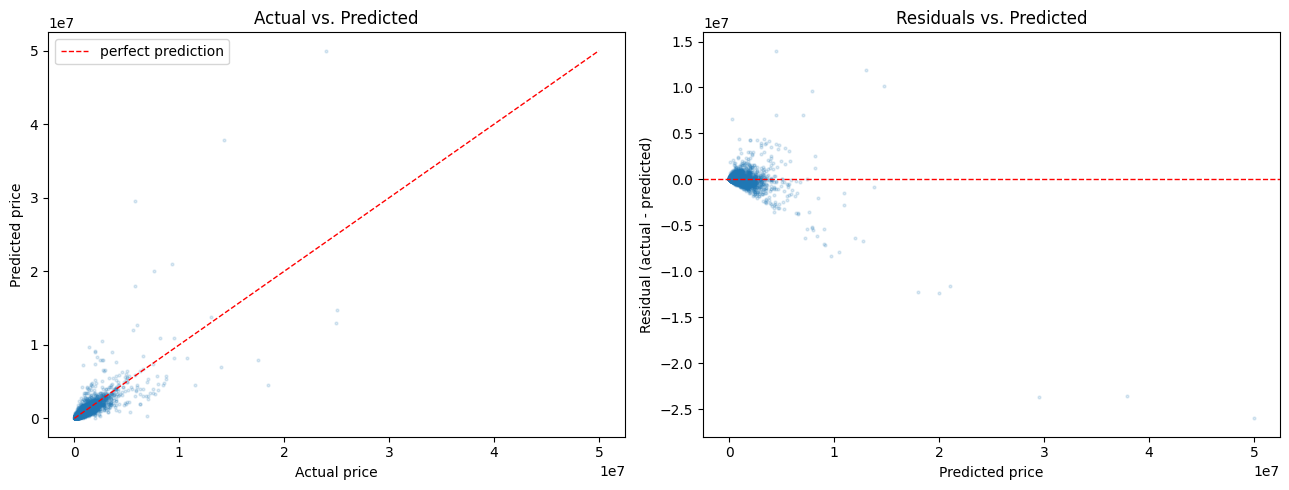

In [70]:
plot_regression_diagnostics(dtree1, X_te_tree, y_te_tree)

#### **Decision Tree — Hyperparameter Tuning**

In [71]:
max_depth_values = np.arange(8, 19, 2)           # center around 12, extend both ways
max_leaf_nodes_values = np.arange(300, 1001, 100) # push well past 300
min_samples_split_values = np.arange(2, 22, 4)


best_estimator = None
best_test_r2 = -float('inf')
best_test_medape = float('inf')
best_score_diff = None

results = []  # keep every combo's scores so you can inspect trade-offs afterward

for max_depth in max_depth_values:
    for max_leaf_nodes in max_leaf_nodes_values:
        for min_samples_split in min_samples_split_values:

            estimator = DecisionTreeRegressor(
                max_depth=max_depth,
                max_leaf_nodes=max_leaf_nodes,
                min_samples_split=min_samples_split,
                random_state=42
            )
            estimator.fit(X_tr_tree, y_tr_tree)

            y_train_pred = estimator.predict(X_tr_tree)
            y_test_pred = estimator.predict(X_te_tree)

            train_r2 = r2_score(y_tr_tree, y_train_pred)
            test_r2 = r2_score(y_te_tree, y_test_pred)

            actual = np.exp(y_te_tree)
            pred = np.exp(y_test_pred)
            test_medape = np.median(np.abs(actual - pred) / actual) * 100

            score_diff = abs(train_r2 - test_r2)

            results.append({
                'max_depth': max_depth, 'max_leaf_nodes': max_leaf_nodes,
                'min_samples_split': min_samples_split,
                'train_r2': train_r2, 'test_r2': test_r2,
                'test_medape': test_medape, 'gap': score_diff,
            })

            # SELECT ON MedAPE instead of R² -- lower is better, with the same overfit guard
            if test_medape < best_test_medape and score_diff < 0.05:
                best_test_medape = test_medape
                best_test_r2 = test_r2
                best_score_diff = score_diff
                best_estimator = estimator

results_df = pd.DataFrame(results)
print(f"Best test MedAPE: {best_test_medape:.2f}%")
print(f"Test R² at that point: {best_test_r2:.4f}")
print(f"Train/test R² gap: {best_score_diff:.4f}")
print(f"Best params: max_depth={best_estimator.max_depth}, "
      f"max_leaf_nodes={best_estimator.max_leaf_nodes}, "
      f"min_samples_split={best_estimator.min_samples_split}")

Best test MedAPE: 13.74%
Test R² at that point: 0.8580
Train/test R² gap: 0.0130
Best params: max_depth=14, max_leaf_nodes=1000, min_samples_split=10


In [72]:
param_grid = {
    "max_depth": [12, 14, 16],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [10, 25, 50],   # dropped 1, dropped 75
    "max_features": [None],              # test sqrt/log2 separately later if curious
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_tr_tree, y_tr_tree)

print("Best params:", grid_search.best_params_)
print("Best CV R²:", grid_search.best_score_)

best_tree = grid_search.best_estimator_
model_performance_regression(best_tree, X_te_tree, y_te_tree)

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Best params: {'max_depth': 14, 'max_features': None, 'min_samples_leaf': 50, 'min_samples_split': 2}
Best CV R²: 0.8621252716667126


,R2,MAE,MedAE,RMSE,MedAPE
0,0.862912,103310.859499,47777.24585,351077.860876,13.235464


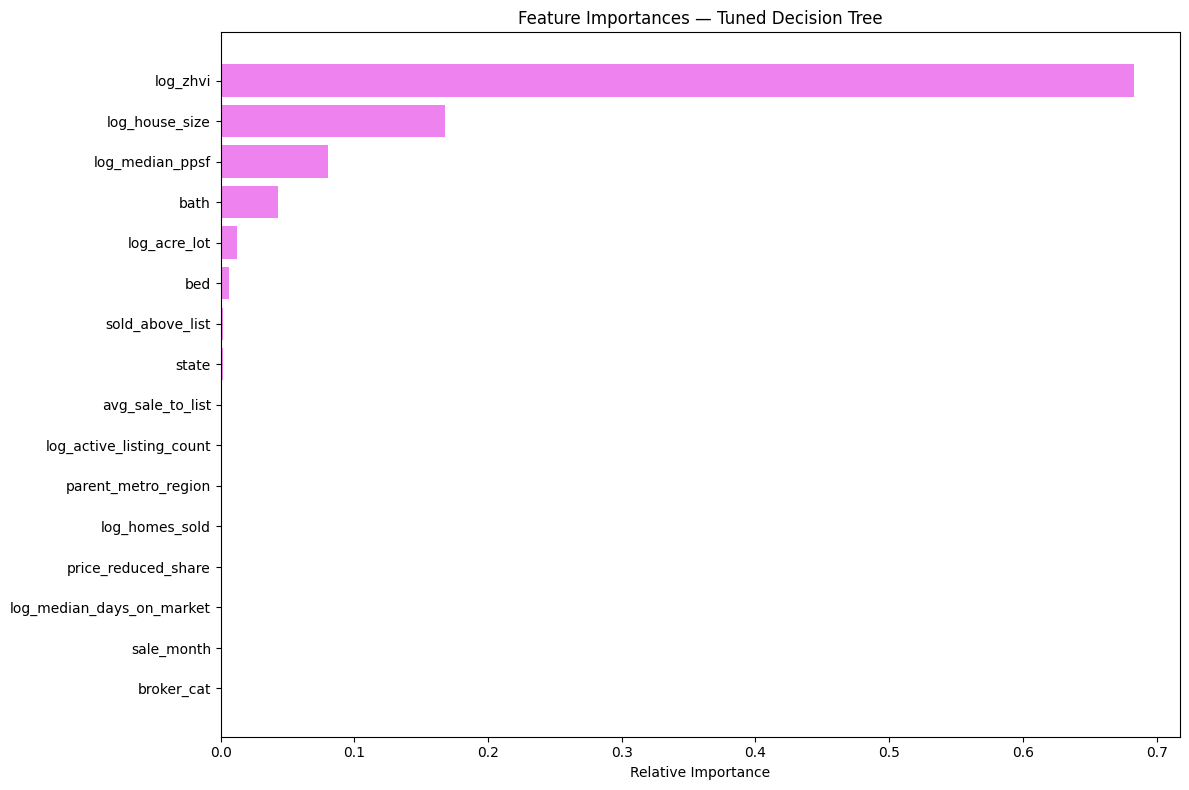

In [73]:
importances = best_tree.feature_importances_
feature_names = X_tr_tree.columns.tolist()  # matches what best_tree was actually trained on
indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.title('Feature Importances — Tuned Decision Tree')
plt.barh(range(len(indices)), importances[indices], color='violet', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

In [74]:
lean_feats = ['log_zhvi', 'log_house_size', 'log_median_ppsf', 'bath']

tr_mask_lean = X_train[lean_feats].notna().all(axis=1)
te_mask_lean = X_test[lean_feats].notna().all(axis=1)

X_tr_lean = X_train.loc[tr_mask_lean, lean_feats]
y_tr_lean = y_train[tr_mask_lean]
X_te_lean = X_test.loc[te_mask_lean, lean_feats]
y_te_lean = y_test[te_mask_lean]

print(f"Train: {len(X_tr_lean):,} of {len(X_train):,}  ({tr_mask_lean.mean()*100:.1f}% retained)")
print(f"Test:  {len(X_te_lean):,} of {len(X_test):,}  ({te_mask_lean.mean()*100:.1f}% retained)")

Train: 531,700 of 646,995  (82.2% retained)
Test:  133,332 of 161,749  (82.4% retained)


In [75]:
lean_tree = DecisionTreeRegressor(
    max_depth=best_tree.max_depth,
    min_samples_split=best_tree.min_samples_split,
    min_samples_leaf=best_tree.min_samples_leaf,
    random_state=42,
)
lean_tree.fit(X_tr_lean, y_tr_lean)

model_performance_regression(lean_tree, X_te_lean, y_te_lean)

,R2,MAE,MedAE,RMSE,MedAPE
0,0.828955,110418.031301,52664.017576,350467.947966,14.835162


In [76]:
common_mask_trees = te_mask_lean & te_mask_tree
common_idx_trees = X_test.index[common_mask_trees]

print(f"Common rows: {len(common_idx_trees):,} "
      f"({len(common_idx_trees) / len(X_test) * 100:.1f}% of test set)")

y_common_trees = y_test.loc[common_idx_trees]

# lean tree
pred_lean = lean_tree.predict(X_test.loc[common_idx_trees, lean_feats])

# full tree needs the same categorical encoding as before
X_common_full = X_test.loc[common_idx_trees, numeric_feats + cat_feats].copy()
for col in cat_feats:
    X_common_full[col] = X_common_full[col].astype(str)
X_common_full[cat_feats] = encoder.transform(X_common_full[cat_feats])
pred_full = best_tree.predict(X_common_full)

for name, pred_log in [('lean_tree', pred_lean), ('best_tree', pred_full)]:
    actual = np.exp(y_common_trees)
    pred = np.exp(pred_log)
    r2 = r2_score(y_common_trees, pred_log)
    medape = np.median(np.abs(actual - pred) / actual) * 100
    print(f"{name:12s}  R²={r2:.4f}  MedAPE={medape:.1f}%")

Common rows: 115,000 (71.1% of test set)
lean_tree     R²=0.8510  MedAPE=14.4%
best_tree     R²=0.8629  MedAPE=13.2%


### **Random Forest**

In [77]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=best_tree.max_depth,
    min_samples_split=best_tree.min_samples_split,
    min_samples_leaf=best_tree.min_samples_leaf,
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_tr_tree, y_tr_tree)

model_performance_regression(rf, X_te_tree, y_te_tree)

,R2,MAE,MedAE,RMSE,MedAPE
0,0.874269,96821.178472,44519.56219,341510.385246,12.308762


In [78]:
common_mask = te_m & te_mask6 & te_mask7 & te_mask_tree
common_idx = X_test.index[common_mask]

print(f"Common test rows: {len(common_idx):,} of {len(X_test):,} "
      f"({len(common_idx) / len(X_test) * 100:.1f}% of test set)")

y_common = y_test.loc[common_idx]
actual_common = np.exp(y_common)

X_common_tree = X_test.loc[common_idx, numeric_feats + cat_feats].copy()
for col in cat_feats:
    X_common_tree[col] = X_common_tree[col].astype(str)
X_common_tree[cat_feats] = encoder.transform(X_common_tree[cat_feats])

fair_models = {
    'A: zhvi + house_size':   (lin_reg_a, X_test.loc[common_idx, feats_a]),
    'B: + bed/bath/acre_lot': (lin_reg6,  X_test.loc[common_idx, ind_vars6]),
    'C: + market activity':   (lin_reg7,  X_test.loc[common_idx, ind_vars7]),
    'Tuned tree':             (best_tree, X_common_tree),
    'Lean tree (4 feat)':     (lean_tree, X_test.loc[common_idx, lean_feats]),
    'Random Forest':          (rf,        X_common_tree),
}

rows = {}
for name, (model, X_sub) in fair_models.items():
    pred_log = model.predict(X_sub)
    pred = np.exp(pred_log)
    rows[name] = [
        r2_score(y_common, pred_log),
        mean_absolute_error(actual_common, pred),
        np.median(np.abs(actual_common - pred)),
        np.sqrt(mean_squared_error(actual_common, pred)),
        np.median(np.abs(actual_common - pred) / actual_common) * 100,
    ]

fair_summary = pd.DataFrame(
    rows, index=['R² (test)', 'MAE ($)', 'MedAE ($)', 'RMSE ($)', 'Median APE (%)']
)

row_formats_fair = {
    'R² (test)': '{:.4f}',
    'MAE ($)': '${:,.0f}',
    'MedAE ($)': '${:,.0f}',
    'RMSE ($)': '${:,.0f}',
    'Median APE (%)': '{:.1f}%',
}

fair_styled = fair_summary.style
for row_label, fmt in row_formats_fair.items():
    fair_styled = fair_styled.format(fmt, subset=pd.IndexSlice[row_label, :])

fair_styled = (
    fair_styled
    .apply(highlight_best, axis=1)
    .set_caption(f"Fair Comparison — same {len(common_idx):,} held-out rows for every model")
)
fair_styled

Common test rows: 115,000 of 161,749 (71.1% of test set)


,A: zhvi + house_size,B: + bed/bath/acre_lot,C: + market activity,Tuned tree,Lean tree (4 feat),Random Forest
R² (test),0.8106,0.8187,0.8195,0.8629,0.8510,0.8743
MAE ($),"$128,767","$126,991","$126,369","$103,311","$107,696","$96,821"
MedAE ($),"$63,090","$62,069","$61,754","$47,777","$51,492","$44,520"
RMSE ($),"$401,159","$386,604","$387,566","$351,078","$343,055","$341,510"
Median APE (%),17.8%,17.4%,17.3%,13.2%,14.4%,12.3%


### **Model Serialization**

In [79]:
from sklearn.preprocessing import OrdinalEncoder, FunctionTransformer
from sklearn.compose import TransformedTargetRegressor, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

In [80]:
log_feats      = ['house_size', 'zhvi', 'median_ppsf']                       # natural log
log1p_feats    = ['acre_lot', 'active_listing_count', 'homes_sold', 'median_days_on_market']  # log1p
passthrough_feats = ['bed', 'bath', 'avg_sale_to_list', 'sold_above_list', 'price_reduced_share', 'sale_month']
cat_feats      = ['state', 'parent_metro_region', 'broker_cat']

raw_feats_all = log_feats + log1p_feats + passthrough_feats + cat_feats

In [81]:
# --- build raw X / y from model_df (mirrors your original mask logic, no log_ columns needed) ---
raw_mask = model_df[raw_feats_all + ['price']].notna().all(axis=1)
X_raw = model_df.loc[raw_mask, raw_feats_all]
y_raw = model_df.loc[raw_mask, 'price']

In [82]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# --- preprocessing: log transforms + categorical encoding, all inside the pipeline ---
preprocessor = make_column_transformer(
    (FunctionTransformer(np.log, feature_names_out="one-to-one"), log_feats),
    (FunctionTransformer(np.log1p, feature_names_out="one-to-one"), log1p_feats),
    (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_feats),
    remainder='passthrough',   # passthrough_feats pass through untouched
)

In [83]:
# --- hardcode the winning hyperparameters from your grid search ---
rf_model = RandomForestRegressor(
     n_estimators=300,
     max_depth=best_tree.max_depth,
     min_samples_split=best_tree.min_samples_split,
     min_samples_leaf=best_tree.min_samples_leaf,
     random_state=42,
    n_jobs=-1,
)

model_with_target_transform = TransformedTargetRegressor(
    regressor=rf_model,
    func=np.log,
    inverse_func=np.exp,
)

final_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', model_with_target_transform),
])

final_pipeline.fit(X_train_raw, y_train_raw)

# sanity check -- this should now return a real dollar figure directly
print(final_pipeline.predict(X_test_raw.iloc[:3]))

[1396050.31114573  418461.14511899 3795808.24246917]


In [84]:
DRIVE_APP_DIR = "/content/drive/MyDrive/Project1_RE_Price_Predictor/app_building"

required = ['zhvi', 'median_ppsf', 'active_listing_count', 'homes_sold',
            'avg_sale_to_list', 'sold_above_list', 'median_days_on_market',
            'price_reduced_share', 'parent_metro_region']

market_snapshot = (
    model_df
    .dropna(subset=required + ['prev_sold_date'])
    .sort_values('prev_sold_date')
    .groupby('zip_code')
    .last()[required + ['state', 'prev_sold_date']]
    .reset_index()
    .rename(columns={'prev_sold_date': 'snapshot_date'})
)

market_snapshot.to_csv(f"{DRIVE_APP_DIR}/market_snapshot_by_zip.csv", index=False)

print(f"Snapshot rows: {len(market_snapshot):,}")
print(f"Total nulls: {market_snapshot.drop(columns='zip_code').isna().sum().sum()}")
print(market_snapshot['snapshot_date'].describe())

Snapshot rows: 13,759
Total nulls: 0
count                            13759
mean     2022-04-11 05:35:13.322189056
min                2021-10-20 00:00:00
25%                2022-04-12 00:00:00
50%                2022-04-22 00:00:00
75%                2022-04-29 00:00:00
max                2022-05-06 00:00:00
Name: snapshot_date, dtype: object


### **Save the model**

In [85]:
DRIVE_APP_DIR = "/content/drive/MyDrive/Project1_RE_Price_Predictor/app_building"
os.makedirs(DRIVE_APP_DIR, exist_ok=True)

In [86]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = f"{DRIVE_APP_DIR}/final_pipeline.joblib"

In [87]:
# Save the best trained model pipeline using joblib
print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at /content/drive/MyDrive/Project1_RE_Price_Predictor/app_building/final_pipeline.joblib


In [88]:
# Load the saved model pipeline from the file

saved_model = joblib.load(saved_model_path)   # = f"{DRIVE_APP_DIR}/final_pipeline.joblib"
print("Model loaded successfully.")


Model loaded successfully.


In [89]:
# Re-save with compression

compressed_path = f"{DRIVE_APP_DIR}/final_pipeline_compressed.joblib"
joblib.dump(saved_model, compressed_path, compress=3)

size_mb = os.path.getsize(compressed_path) / (1024 * 1024)
print(f"Compressed size: {size_mb:.1f} MB")

Compressed size: 46.1 MB


In [90]:
saved_model

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('functiontransformer-1',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log'>),
                                                  ['house_size', 'zhvi',
                                                   'median_ppsf']),
                                                 ('functiontransformer-2',
                                                  FunctionTransformer(feature_names_out='one-to-one',
                                                                      func=<ufunc 'log1p'>),
                                                  ['acre_lot',
                                                   'active_listing_count',...
                                                   'median_days_on_market']),
                                                 ('ordinalencoder',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['state',
                                                   'parent_metro_region',
                                                   'broker_cat'])])),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log'>,
                                            inverse_func=<ufunc 'exp'>,
                                            regressor=RandomForestRegressor(max_depth=14,
                                                                            min_samples_leaf=50,
                                                                            n_estimators=300,
                                                                            n_jobs=-1,
                                                                            random_state=42)))])

In [91]:
# test the saved model
preds = saved_model.predict(X_test_raw.iloc[:5])
print("Predicted:", preds)
print("Actual:   ", y_test_raw.iloc[:5].values)

Predicted: [1396050.31114573  418461.14511899 3795808.24246917  368395.84753143
  184413.67268537]
Actual:    [ 1375000.   419000. 11900000.   369900.   199900.]


In [92]:
from sklearn.metrics import r2_score, mean_absolute_error

preds_all = saved_model.predict(X_test_raw)

print(f"R²:  {r2_score(y_test_raw, preds_all):.4f}")
print(f"MAE: ${mean_absolute_error(y_test_raw, preds_all):,.0f}")

R²:  0.7094
MAE: $96,722
